# Model 1 - UNet 

In [ ]:
import subprocess, sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'],stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _pkg in ['medpy', 'albumentations']:
    try:
        __import__(_pkg)
    except ImportError:
        print(f'Installing {_pkg}…')
        _pip_install(_pkg)

print('All dependencies ready')

Installing medpy…
All dependencies ready


In [ ]:
import os, glob, random, warnings, time
import numpy as np
import pandas as pd
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
from matplotlib.gridspec import GridSpec
from pathlib import Path
from copy import deepcopy
from torch.utils.data import Dataset, DataLoader, random_split
from torch.cuda.amp import GradScaler, autocast
from albumentations.pytorch import ToTensorV2
from medpy.metric.binary import hd95

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')

PyTorch  : 2.10.0+cu128
CUDA     : True (Tesla T4)


In [4]:
class CFG:
    SEED = 67
    IMAGE_SIZE = 224
    BATCH_SIZE = 8
    LR = 1e-4
    EPOCHS = 50
    WEIGHT_DECAY = 1e-5
    UNET_FEATURES = [64, 128, 256, 512]
    IN_CHANNELS = 1
    OUT_CHANNELS = 1
    DATA_ROOT = Path('/kaggle/input/datasets/prabhanshu22/dac-dataset-skull/processed_skull')
    TRAIN_DIR = DATA_ROOT / 'train'
    VAL_DIR = DATA_ROOT / 'val'
    TEST_DIR = DATA_ROOT / 'test'
    CKPT_DIR = Path('/kaggle/working/models')
    BEST_CKPT = CKPT_DIR / 'unet_best.pth'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    FOCAL_ALPHA = 0.25  
    FOCAL_GAMMA = 2.0
    FOCAL_WEIGHT = 0.5    
    DICE_WEIGHT = 0.5    

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.SEED)
CFG.CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f'  Config set  |  Device: {CFG.DEVICE}  |  Seed: {CFG.SEED}')
print(f'  Image size  : {CFG.IMAGE_SIZE}x{CFG.IMAGE_SIZE}')
print(f'  Batch size  : {CFG.BATCH_SIZE}  |  LR: {CFG.LR}  |  Epochs: {CFG.EPOCHS}')
print(f'  U-Net feats : {CFG.UNET_FEATURES}')
print(f'  Focal α={CFG.FOCAL_ALPHA}, γ={CFG.FOCAL_GAMMA}  |  '
      f'Loss = {CFG.FOCAL_WEIGHT}×Focal + {CFG.DICE_WEIGHT}×Dice')

  Config set  |  Device: cuda  |  Seed: 67
  Image size  : 224x224
  Batch size  : 8  |  LR: 0.0001  |  Epochs: 50
  U-Net feats : [64, 128, 256, 512]
  Focal α=0.25, γ=2.0  |  Loss = 0.5×Focal + 0.5×Dice


## Loading the data 

In [5]:
class BRISCDataset(Dataset):
    def __init__(self, split_dir: Path, transform=None):
        self.transform = transform
        self.image_paths = sorted((split_dir / 'images').glob('*.npy'))
        self.mask_paths = [split_dir / 'masks' / p.name for p in self.image_paths]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.load(self.image_paths[idx]).astype(np.float32)
        mask = np.load(self.mask_paths[idx]).astype(np.float32)
        
        if img.ndim == 3:
            img = img[..., 0] if img.shape[-1] <= 4 else img[0]
        mn, mx = img.min(), img.max()
        img = (img - mn) / (mx - mn + 1e-8)
        img_3ch = np.stack([img, img, img], axis=-1).astype(np.float32)
        mask_2d = (mask > 0.5).astype(np.float32)

        if self.transform:
            out = self.transform(image=img_3ch, mask=mask_2d)
            img_t = out['image'][:1]
            mask_t = out['mask'].unsqueeze(0).float()
        else:
            img_t = torch.from_numpy(img_3ch.transpose(2,0,1))[:1]
            mask_t = torch.from_numpy(mask_2d).unsqueeze(0)

        return img_t, mask_t

In [6]:
SZ = CFG.IMAGE_SIZE

def get_train_transforms():
    return A.Compose([
        A.Resize(SZ, SZ),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
        A.ElasticTransform(alpha=120, sigma=6, alpha_affine=6, p=0.4),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.15,contrast_limit=0.15, p=0.4),
        A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
        A.Normalize(mean=(0.0,), std=(1.0,)),
        ToTensorV2(),
    ])

def get_val_transforms():
    return A.Compose([A.Resize(SZ, SZ), A.Normalize(mean=(0.0,), std=(1.0,)), ToTensorV2(),])

In [7]:
train_ds = BRISCDataset(CFG.TRAIN_DIR, transform=get_train_transforms())
val_ds = BRISCDataset(CFG.VAL_DIR,   transform=get_val_transforms())
test_ds = BRISCDataset(CFG.TEST_DIR,  transform=get_val_transforms())

_kw = dict(batch_size=CFG.BATCH_SIZE, num_workers=2, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **_kw)
val_loader = DataLoader(val_ds,   shuffle=False, **_kw)
test_loader = DataLoader(test_ds,  shuffle=False, **_kw)

print(f'Train : {len(train_ds):>5} slices  ({len(train_loader):>4} batches)')
print(f'Val   : {len(val_ds):>5} slices  ({len(val_loader):>4} batches)')
print(f'Test  : {len(test_ds):>5} slices  ({len(test_loader):>4} batches)')

imgs, masks = next(iter(train_loader))
print(f'\nBatch → image {tuple(imgs.shape)}  mask {tuple(masks.shape)}')
print(f'Image range [{imgs.min():.3f}, {imgs.max():.3f}]  |  Mask unique {masks.unique().tolist()}')

Train :  3343 slices  ( 418 batches)
Val   :   590 slices  (  74 batches)
Test  :   860 slices  ( 108 batches)

Batch → image (8, 1, 224, 224)  mask (8, 1, 224, 224)
Image range [0.000, 0.004]  |  Mask unique [0.0, 1.0]


## Architecture — U-Net

In [8]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, mid_ch: int = None):
        super().__init__()
        mid_ch = mid_ch or out_ch
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  mid_ch,  3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, out_ch,  3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.pool  = nn.MaxPool2d(2)
        self.conv  = DoubleConv(in_ch, out_ch)
        
    def forward(self, x):
        return self.conv(self.pool(x))

class DecoderBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_ch + skip_ch, out_ch)
        
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:],mode='bilinear', align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))


class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, features=None):
        super().__init__()
        features = features or CFG.UNET_FEATURES
        bottleneck = features[-1] * 2

        self.enc0 = DoubleConv(in_ch, features[0])
        self.enc1 = EncoderBlock(features[0], features[1])
        self.enc2 = EncoderBlock(features[1], features[2])
        self.enc3 = EncoderBlock(features[2], features[3])
        self.bottleneck = EncoderBlock(features[3], bottleneck)
        self.dec3 = DecoderBlock(bottleneck,  features[3], features[3])
        self.dec2 = DecoderBlock(features[3], features[2], features[2])
        self.dec1 = DecoderBlock(features[2], features[1], features[1])
        self.dec0 = DecoderBlock(features[1], features[0], features[0])
        self.head = nn.Conv2d(features[0], out_ch, kernel_size=1)

    def forward(self, x):
        s0 = self.enc0(x)
        s1 = self.enc1(s0)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        b = self.bottleneck(s3)
        d = self.dec3(b,  s3)
        d = self.dec2(d,  s2)
        d = self.dec1(d,  s1)
        d = self.dec0(d,  s0)
        return self.head(d)

In [9]:
model = UNet(in_ch=CFG.IN_CHANNELS, out_ch=CFG.OUT_CHANNELS, features=CFG.UNET_FEATURES).to(CFG.DEVICE)

def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def print_param_summary(m):
    header = f"{'Layer':<30} {'Output shape':<22} {'Params':>12}"
    print('─' * len(header))
    print(header)
    print('─' * len(header))
    for name, mod in m.named_children():
        p = sum(x.numel() for x in mod.parameters())
        print(f'{name:<30} {str(type(mod).__name__):<22} {p:>12,}')
    print('─' * len(header))
    tot, trn = count_params(m)
    print(f"{'Total parameters':<30} {'':22} {tot:>12,}")
    print(f"{'Trainable parameters':<30} {'':22} {trn:>12,}")
    print('─' * len(header))

print_param_summary(model)
tot, _ = count_params(model)
print(f'\n  ≈ {tot/1e6:.2f} M parameters')

──────────────────────────────────────────────────────────────────
Layer                          Output shape                 Params
──────────────────────────────────────────────────────────────────
enc0                           DoubleConv                   37,696
enc1                           EncoderBlock                221,696
enc2                           EncoderBlock                885,760
enc3                           EncoderBlock              3,540,992
bottleneck                     EncoderBlock             14,159,872
dec3                           DecoderBlock              9,439,232
dec2                           DecoderBlock              2,360,320
dec1                           DecoderBlock                590,336
dec0                           DecoderBlock                147,712
head                           Conv2d                           65
──────────────────────────────────────────────────────────────────
Total parameters                                        31,383

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0,reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor,targets: torch.Tensor) -> torch.Tensor:
        
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')  
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1.0 - probs) * (1.0 - targets)
        alpha_t = self.alpha * targets + (1.0 - self.alpha) * (1.0 - targets)
        focal_weight = (1.0 - p_t) ** self.gamma
        focal_loss = alpha_t * focal_weight * bce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss  

class FocalDiceLoss(nn.Module):
    def __init__(self,
                 alpha: float = CFG.FOCAL_ALPHA,
                 gamma: float = CFG.FOCAL_GAMMA,
                 focal_weight: float = CFG.FOCAL_WEIGHT,
                 dice_weight: float = CFG.DICE_WEIGHT,
                 smooth: float = 1e-6):
        super().__init__()
        self.focal = FocalLoss(alpha=alpha, gamma=gamma)
        self.w_focal = focal_weight
        self.w_dice = dice_weight
        self.smooth = smooth

    def dice_loss(self, logits: torch.Tensor,targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        num = 2 * (probs * targets).sum(dim=(2, 3)) + self.smooth
        den = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) + self.smooth
        return 1.0 - (num / den).mean()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return (self.w_focal * self.focal(logits, targets) + self.w_dice  * self.dice_loss(logits, targets))

criterion = FocalDiceLoss(
    alpha = CFG.FOCAL_ALPHA,
    gamma = CFG.FOCAL_GAMMA,
    focal_weight = CFG.FOCAL_WEIGHT,
    dice_weight = CFG.DICE_WEIGHT,
).to(CFG.DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR( optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)

print(f'Focal: α={CFG.FOCAL_ALPHA}, γ={CFG.FOCAL_GAMMA}')
print(f'Loss weights: {CFG.FOCAL_WEIGHT}×Focal + {CFG.DICE_WEIGHT}×Dice')

Focal: α=0.25, γ=2.0
Loss weights: 0.5×Focal + 0.5×Dice


## Training

In [11]:
def dice_score(pred_bin: np.ndarray, target: np.ndarray, smooth: float = 1e-6) -> float:
    inter = (pred_bin * target).sum()
    return (2 * inter + smooth) / (pred_bin.sum() + target.sum() + smooth)

def iou_score(pred_bin: np.ndarray, target: np.ndarray, smooth: float = 1e-6) -> float:
    inter = (pred_bin * target).sum()
    union = pred_bin.sum() + target.sum() - inter
    return (inter + smooth) / (union + smooth)

def batch_metrics(logits: torch.Tensor, masks: torch.Tensor, threshold: float = 0.5):
    probs = torch.sigmoid(logits).detach().cpu().numpy()
    masks_np = masks.cpu().numpy()
    preds = (probs > threshold).astype(np.float32)
    dices, ious = [], []
    for p, t in zip(preds, masks_np):
        dices.append(dice_score(p, t))
        ious.append(iou_score(p, t))
    return np.mean(dices), np.mean(ious)

In [12]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None, device=CFG.DEVICE, train=True):
    model.train(train)
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)

            if train:
                optimizer.zero_grad()
                with autocast():
                    logits = model(imgs)
                    loss   = criterion(logits, masks)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast():
                    logits = model(imgs)
                    loss   = criterion(logits, masks)

            d, iou = batch_metrics(logits, masks)
            total_loss += loss.item()
            total_dice += d
            total_iou  += iou

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n

In [13]:
scaler = GradScaler()

history = {'train_loss':[],'val_loss':[],'train_dice':[],'val_dice':[],'train_iou':[],'val_iou':[],'lr': [],}

best_val_dice = -1.0
best_epoch    = 0

hdr = (f"{'Epoch':>6}  {'T-Loss':>8}  {'V-Loss':>8}  "
       f"{'T-Dice':>8}  {'V-Dice':>8}  {'V-IoU':>8}  "
       f"{'LR':>10}  {'Time':>7}")
print(hdr)
print('─' * len(hdr))

for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_dice, tr_iou = run_epoch(model, train_loader, criterion,optimizer, scaler, train=True)
    va_loss, va_dice, va_iou = run_epoch(model, val_loader, criterion,train=False)
    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_dice'].append(tr_dice)
    history['val_dice'].append(va_dice)
    history['train_iou'].append(tr_iou)
    history['val_iou'].append(va_iou)
    history['lr'].append(cur_lr)

    saved_flag = ''
    if va_dice > best_val_dice:
        best_val_dice = va_dice
        best_epoch = epoch
        torch.save({
            'epoch':      epoch,
            'state_dict': deepcopy(model.state_dict()),
            'val_dice':   float(va_dice),
            'val_iou':    float(va_iou),
        }, CFG.BEST_CKPT)
        saved_flag = ' ★'

    elapsed = time.time() - t0
    print(f'{epoch:>6}  {tr_loss:>8.4f}  {va_loss:>8.4f}  '
          f'{tr_dice:>8.4f}  {va_dice:>8.4f}  {va_iou:>8.4f}  '
          f'{cur_lr:>10.2e}  {elapsed:>6.1f}s{saved_flag}')

print('─' * len(hdr))
print(f'\nTraining complete  |  Best Val Dice: {best_val_dice:.4f} @ epoch {best_epoch}')

 Epoch    T-Loss    V-Loss    T-Dice    V-Dice     V-IoU          LR     Time
─────────────────────────────────────────────────────────────────────────────
     1    0.4725    0.4391    0.3752    0.5318    0.4077    9.99e-05    89.1s ★
     2    0.4113    0.3168    0.5108    0.6774    0.5771    9.96e-05    93.2s ★
     3    0.3190    0.2295    0.5783    0.6996    0.5953    9.91e-05    92.8s ★
     4    0.2418    0.1781    0.6284    0.7213    0.6315    9.84e-05    92.8s ★
     5    0.2105    0.1656    0.6427    0.7193    0.6247    9.76e-05    91.8s
     6    0.1894    0.1492    0.6668    0.7400    0.6399    9.65e-05    92.0s ★
     7    0.1809    0.1375    0.6746    0.7563    0.6617    9.53e-05    92.2s ★
     8    0.1735    0.1255    0.6842    0.7760    0.6870    9.39e-05    92.1s ★
     9    0.1665    0.1201    0.6944    0.7819    0.6886    9.23e-05    92.0s ★
    10    0.1638    0.1221    0.6979    0.7760    0.6888    9.05e-05    92.0s
    11    0.1622    0.1231    0.6990    0.7727  

## Evaluation

In [14]:
ckpt = torch.load(CFG.BEST_CKPT, map_location=CFG.DEVICE, weights_only=False)

model.load_state_dict(ckpt['state_dict'])
model.eval()

print(f'Loaded best checkpoint  (epoch {int(ckpt["epoch"])}, '
      f'Val Dice = {float(ckpt["val_dice"]):.4f})')

Loaded best checkpoint  (epoch 48, Val Dice = 0.8585)


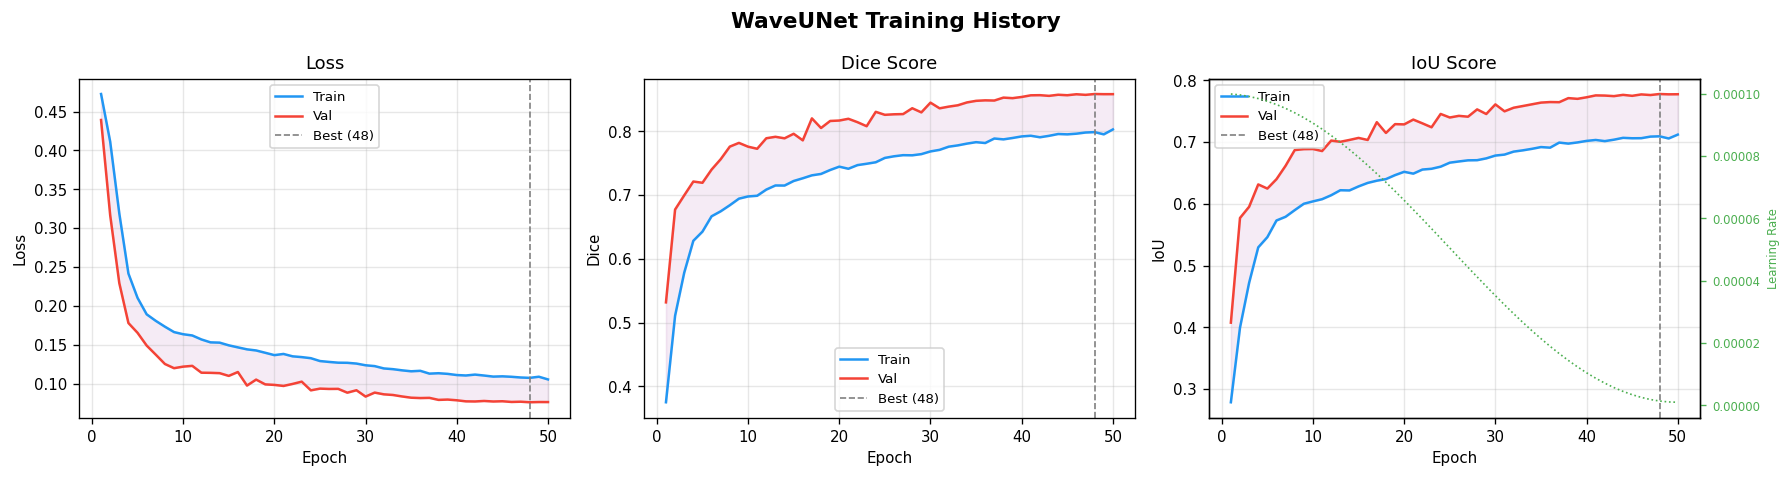

In [ ]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('UNet Training History', fontsize=13, fontweight='bold')

palette = {'train': '#2196F3', 'val': '#F44336'}

for ax, (tr_key, va_key, title, ylabel) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss',       'Loss'),
    ('train_dice', 'val_dice', 'Dice Score', 'Dice'),
    ('train_iou',  'val_iou',  'IoU Score',  'IoU'),
]):
    ax.plot(epochs, history[tr_key], label='Train', color=palette['train'], lw=1.5)
    ax.plot(epochs, history[va_key], label='Val',   color=palette['val'],   lw=1.5)
    ax.axvline(best_epoch, ls='--', color='gray', lw=1, label=f'Best ({best_epoch})')
    ax.fill_between(epochs, history[tr_key], history[va_key],alpha=0.08, color='purple')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# LR inset in axis 2
ax2b = axes[2].twinx()
ax2b.plot(epochs, history['lr'], color='#4CAF50', lw=1, ls='dotted', label='LR')
ax2b.set_ylabel('Learning Rate', color='#4CAF50', fontsize=7)
ax2b.tick_params(axis='y', colors='#4CAF50', labelsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/unet_history.png', bbox_inches='tight')
plt.show()

In [16]:
@torch.no_grad()
def evaluate_metrics(model, loader, device=CFG.DEVICE, threshold=0.5):
    model.eval()
    records = []

    for imgs, masks in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > threshold).astype(np.uint8)
        gts = masks.numpy().astype(np.uint8)

        for pred, gt in zip(preds, gts):
            p = pred[0]; t = gt[0]
            tp = (p & t).sum()
            tn = ((1-p) & (1-t)).sum()
            fp = (p & (1-t)).sum()
            fn = ((1-p) & t).sum()

            dice = (2*tp + 1e-6) / (2*tp + fp + fn + 1e-6)
            iou = (tp + 1e-6)   / (tp + fp + fn + 1e-6)
            prec = (tp + 1e-6)   / (tp + fp + 1e-6)
            rec = (tp + 1e-6)   / (tp + fn + 1e-6)
            spec = (tn + 1e-6)   / (tn + fp + 1e-6)

            if p.sum() > 0 and t.sum() > 0:
                _hd95 = hd95(p, t)
            else:
                _hd95 = np.nan

            records.append(dict(dice=dice, iou=iou, hd95=_hd95,
                                precision=prec, recall=rec,specificity=spec))
    return records

def summarise(records, label):
    df  = pd.DataFrame(records)
    row = {}
    for col in df.columns:
        vals  = df[col].dropna()
        row[f'{col}_mean'] = vals.mean()
        row[f'{col}_std']  = vals.std()
    row['split'] = label
    return row

print('Evaluating Training Data')
tr_records = evaluate_metrics(model, train_loader)
print('Evaluating Validation Data')
va_records = evaluate_metrics(model, val_loader)
print('Evaluating Testing Data')
te_records = evaluate_metrics(model, test_loader)

summary_df = pd.DataFrame([summarise(tr_records, 'Train'),summarise(va_records, 'Val'),summarise(te_records, 'Test'),]).set_index('split')

metrics_order = ['dice', 'iou', 'hd95', 'precision', 'recall', 'specificity']
disp = pd.DataFrame(index=summary_df.index)
for m in metrics_order:
    disp[m.capitalize()] = (summary_df[f'{m}_mean'].map('{:.4f}'.format) + ' ± ' + summary_df[f'{m}_std'].map('{:.4f}'.format))

print('\nMetric Summary\n')
print(disp.to_string())

Evaluating Training Data
Evaluating Validation Data
Evaluating Testing Data

Metric Summary

                  Dice              Iou               Hd95        Precision           Recall      Specificity
split                                                                                                        
Train  0.8003 ± 0.2298  0.7119 ± 0.2387  10.4687 ± 17.1288  0.8348 ± 0.2200  0.8151 ± 0.2377  0.9977 ± 0.0040
Val    0.8587 ± 0.1622  0.7781 ± 0.1851   7.8802 ± 13.4386  0.8785 ± 0.1725  0.8673 ± 0.1710  0.9982 ± 0.0033
Test   0.8482 ± 0.1880  0.7699 ± 0.2101   8.6241 ± 16.2359  0.8622 ± 0.1946  0.8692 ± 0.1881  0.9980 ± 0.0037


## Visualizations 


In [ ]:
from scipy.ndimage import binary_erosion
import random as _random

def get_boundary(binary_mask, thickness=2):
    eroded = binary_erosion(binary_mask.astype(bool), iterations=thickness)
    return binary_mask.astype(bool) & ~eroded

def build_boundary_overlay(img, gt_mask, pred_mask):
    gt_b   = get_boundary(gt_mask.astype(bool))
    pred_b = get_boundary(pred_mask.astype(bool))
    both   = gt_b & pred_b

    rgb = np.stack([img, img, img], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    rgb[gt_b,0] = 0.0
    rgb[gt_b,1] = 1.0
    rgb[gt_b,2] = 0.0
    rgb[pred_b,0] = 1.0
    rgb[pred_b,1] = 0.0
    rgb[pred_b,2] = 0.0
    rgb[both,0] = 1.0
    rgb[both,1] = 1.0
    rgb[both,2] = 0.0
    return rgb

def iou_from_masks(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    inter = (gt & pred).sum()
    union = (gt | pred).sum()
    return (inter / union * 100) if union > 0 else 0.0

def plot_5_grid(samples_list, title, fname):
    from matplotlib.patches import Patch
    n = len(samples_list)
    fig, axes = plt.subplots(n, 4, figsize=(13, 3.6*n))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    col_titles = ['Input MRI', 'Ground Truth', 'Predicted Mask', 'Boundary Overlap']
    for col, t in enumerate(col_titles):
        axes[0][col].set_title(t, fontsize=11, fontweight='bold')

    for row, s in enumerate(samples_list):
        img  = s['image']
        gt   = s['gt'].astype(bool)
        pred = s['pred'].astype(bool)
        ovl  = build_boundary_overlay(img, gt, pred)
        iou  = iou_from_masks(gt, pred)

        axes[row][0].imshow(img,cmap='gray')
        axes[row][1].imshow(gt,cmap='gray')
        axes[row][2].imshow(pred,cmap='gray')
        axes[row][3].imshow(ovl)
        axes[row][3].text(0.98, 0.02, f'IoU: {iou:.1f}%',transform=axes[row][3].transAxes,fontsize=9, fontweight='bold', 
                          color='white',ha='right', va='bottom',bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6))
        axes[row][0].set_ylabel(f"Dice: {s['dice']:.4f}", fontsize=10)
        for col in range(4):
            axes[row][col].axis('off')

    legend = [mpatches.Patch(facecolor='green',  label='GT boundary'),
        mpatches.Patch(facecolor='red',    label='Pred boundary'),
        mpatches.Patch(facecolor='yellow', label='Intersection'),]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.75, -0.01), framealpha=0.8)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

print('Collecting all test-set predictions …')
model.eval()
_all_samples = []
with torch.no_grad():
    for _imgs, _masks in test_loader:
        _logits = model(_imgs.to(CFG.DEVICE))
        _preds  = (torch.sigmoid(_logits) > 0.5).cpu().numpy().astype(np.float32)
        for _i in range(len(_imgs)):
            _p = _preds[_i, 0];  _m = _masks[_i, 0].numpy()
            _d = float((2*(_p*_m).sum() + 1e-6) / (_p.sum() + _m.sum() + 1e-6))
            _all_samples.append({'image': _imgs[_i, 0].numpy(),'gt':_m, 'pred': _p,'dice': _d})

_all_sorted = sorted(_all_samples, key=lambda x: x['dice'], reverse=True)
print(f'  Total test samples : {len(_all_samples)}')
print(f'  Best  Dice : {_all_sorted[0]["dice"]:.4f}')
print(f'  Worst Dice : {_all_sorted[-1]["dice"]:.4f}')


  Total test samples : 860
  Best  Dice : 0.9869
  Worst Dice : 0.0000


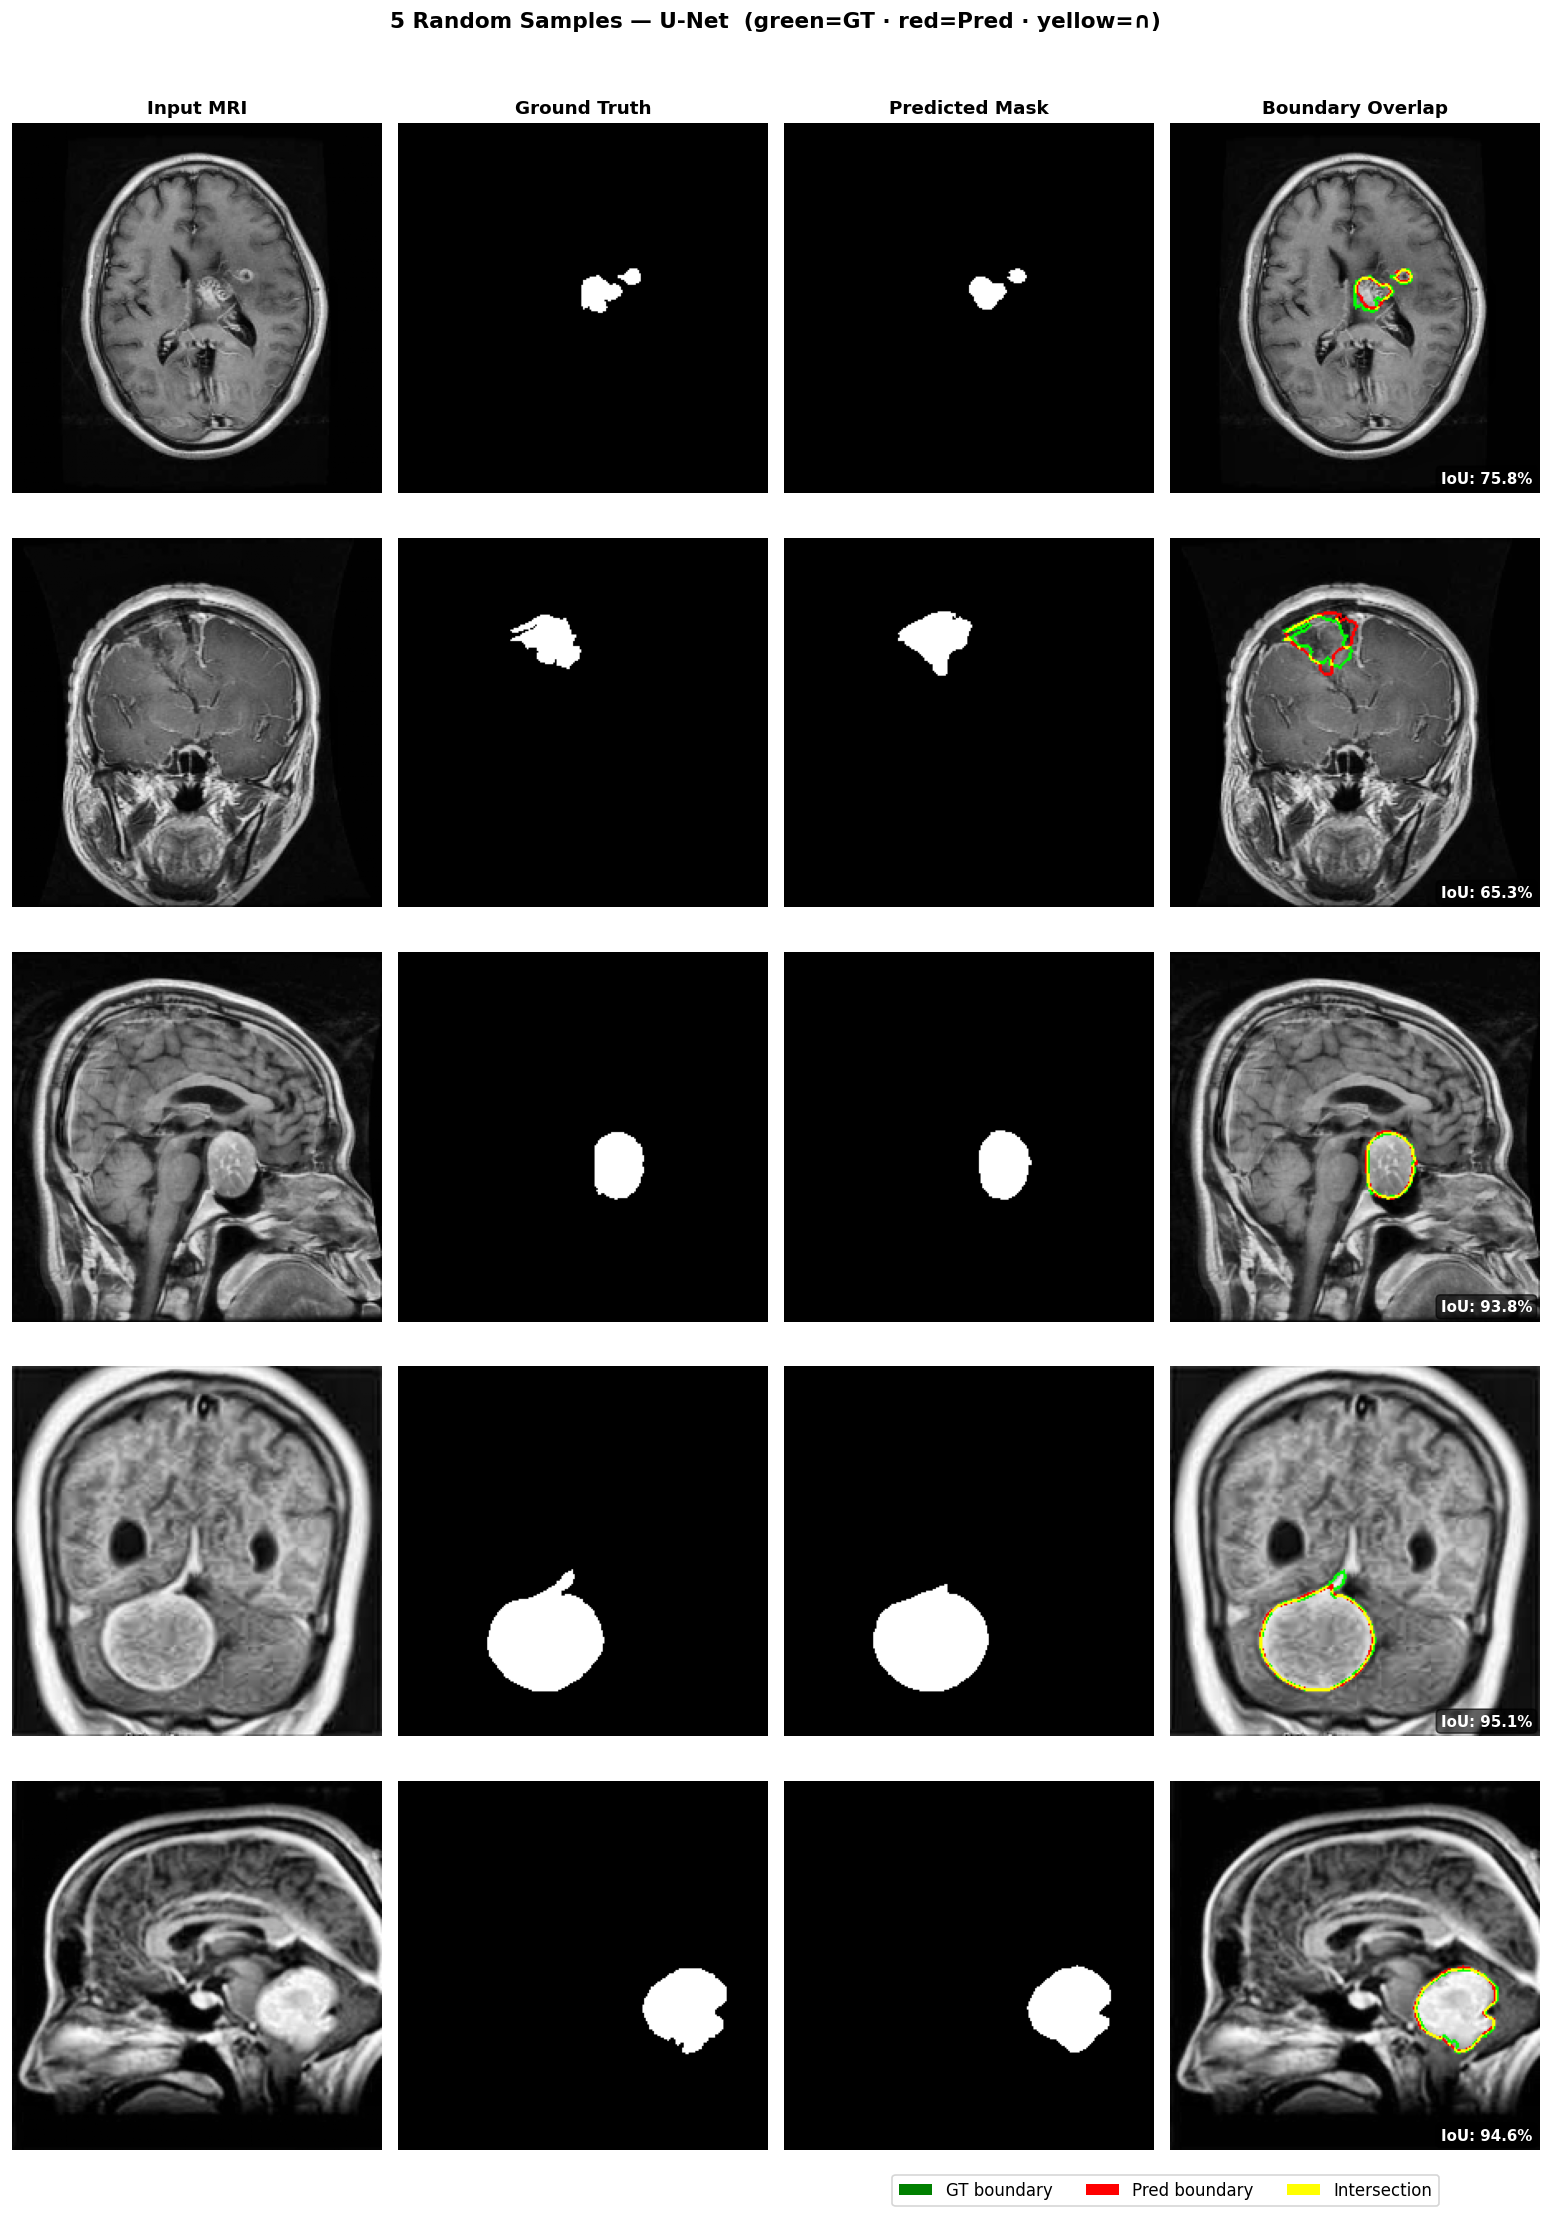

In [ ]:
_random.seed(CFG.SEED)
random_5 = _random.sample(_all_samples, 5)
plot_5_grid(random_5,title='5 Random Samples — U-Net  (green=GT · red=Pred · yellow=∩)',fname='/kaggle/working/viz_random_5.png')

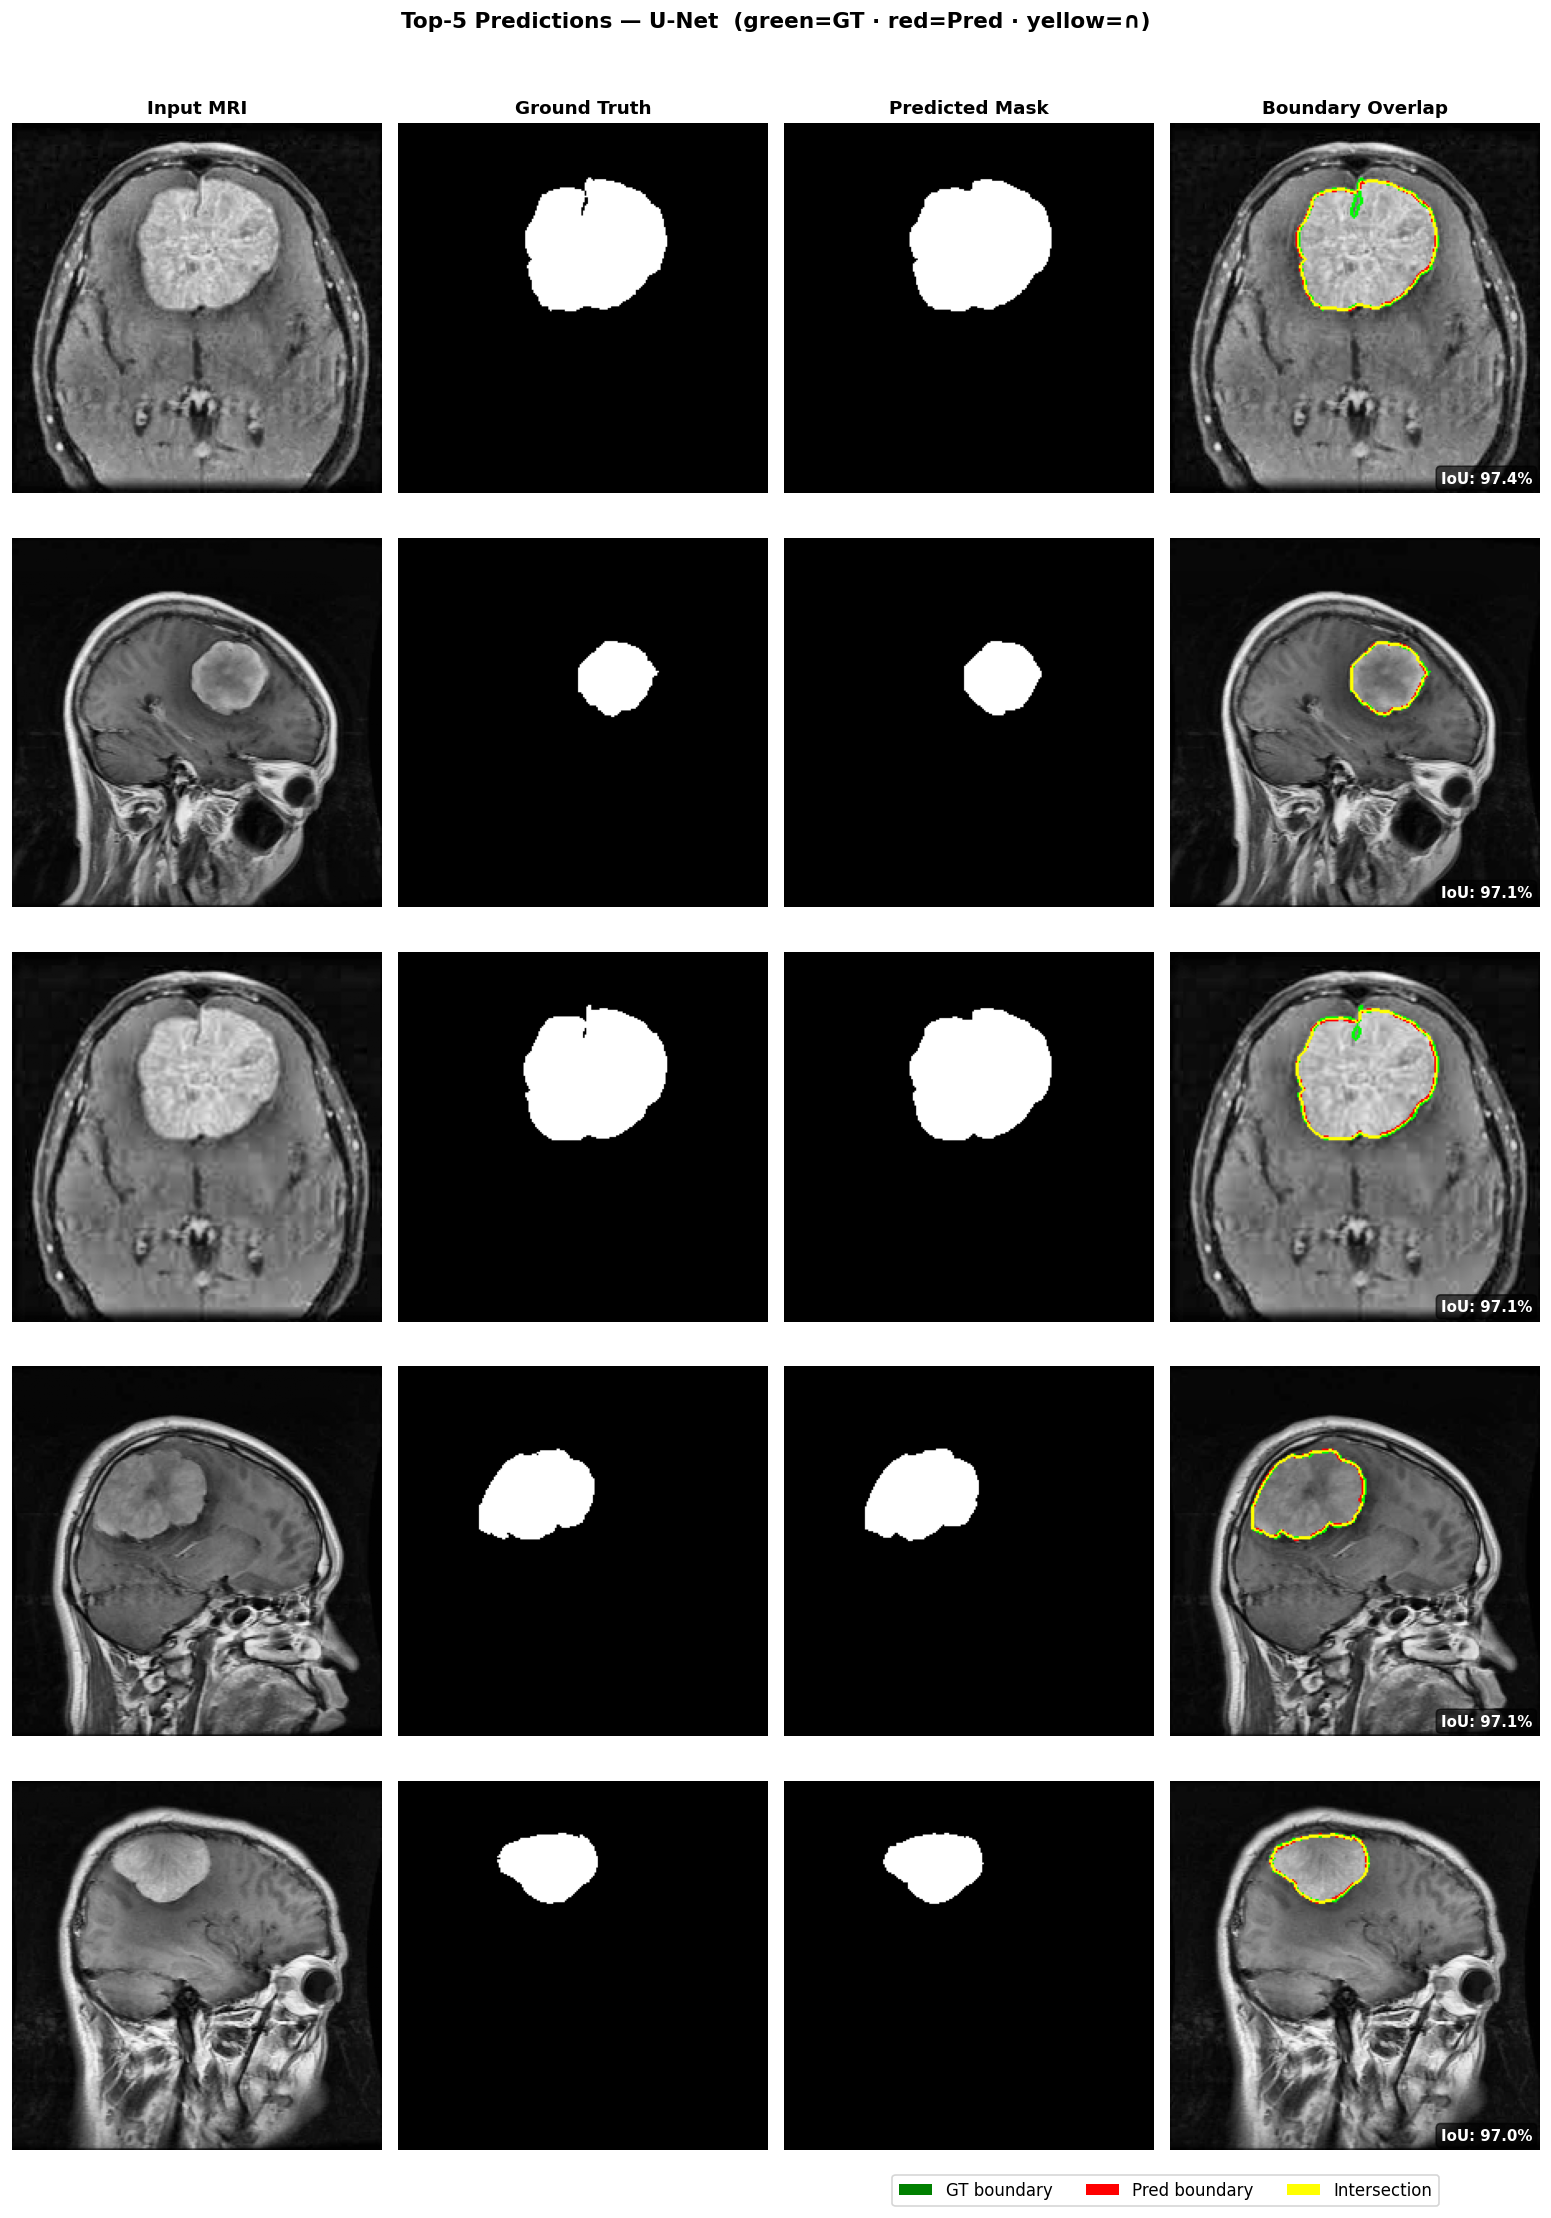

In [ ]:
top_5 = _all_sorted[:5]
plot_5_grid(top_5,title='Top-5 Predictions — U-Net  (green=GT · red=Pred · yellow=∩)',fname='/kaggle/working/viz_top_5.png')

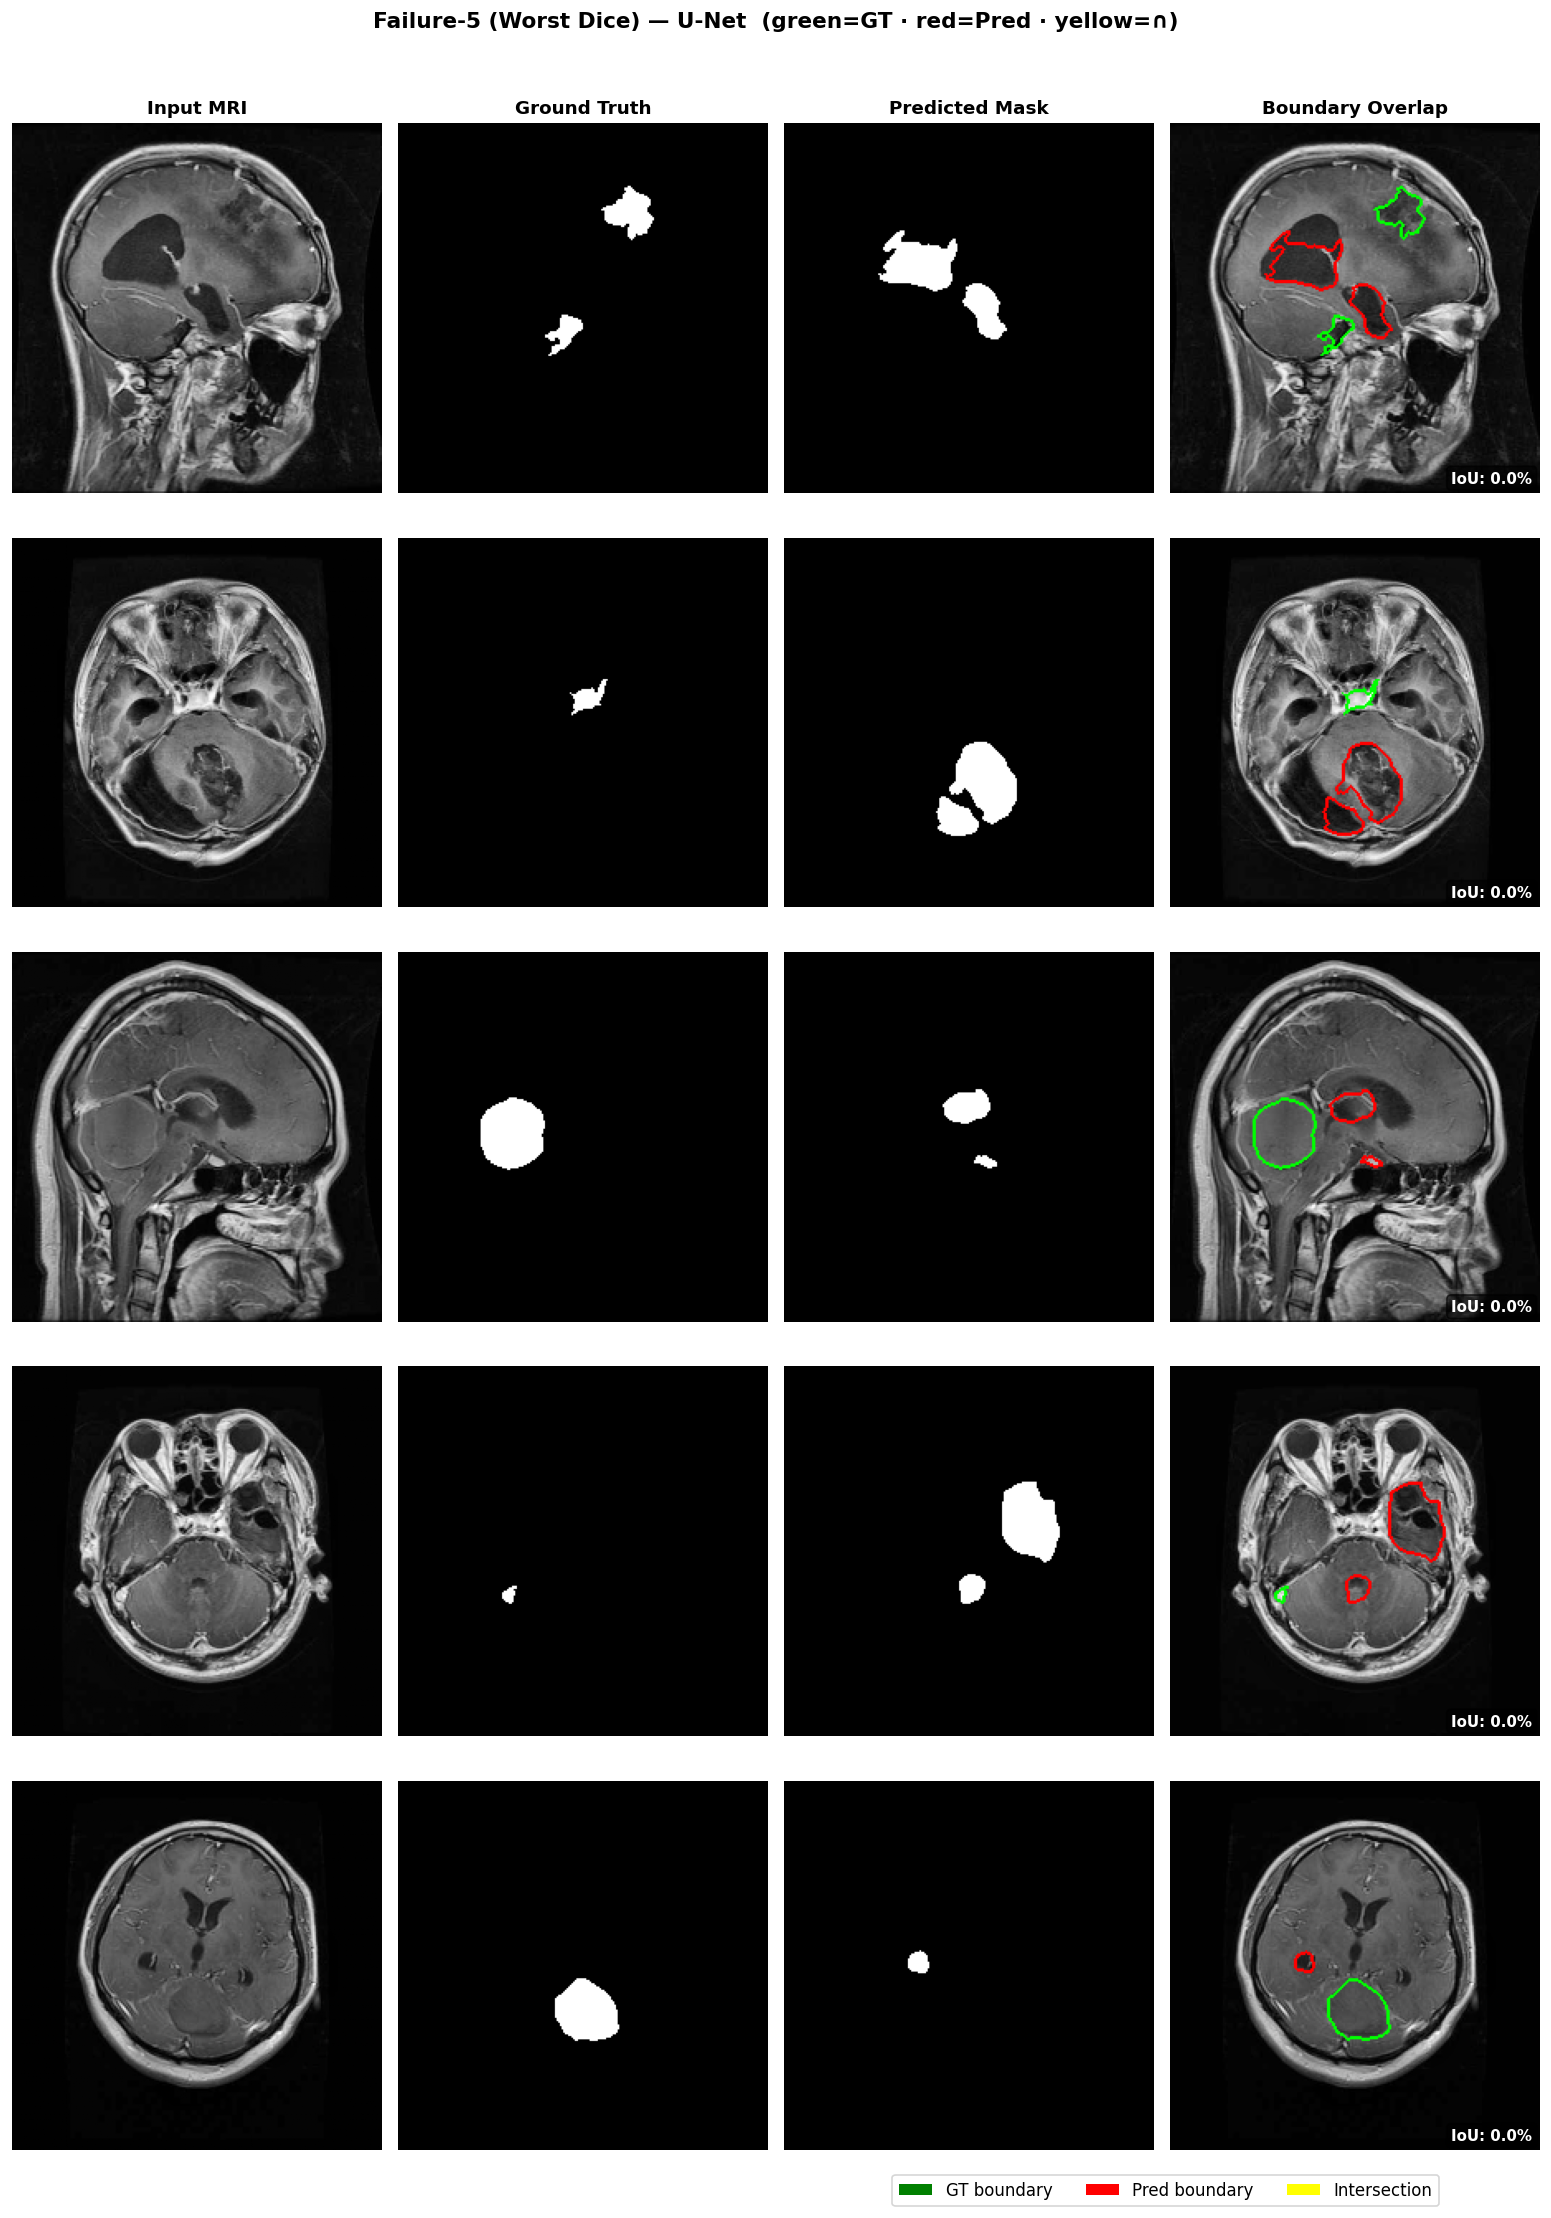

In [ ]:
fail_5 = _all_sorted[-5:][::-1]
plot_5_grid(fail_5,title='Failure-5 (Worst Dice) — U-Net  (green=GT · red=Pred · yellow=∩)',fname='/kaggle/working/viz_failure_5.png')

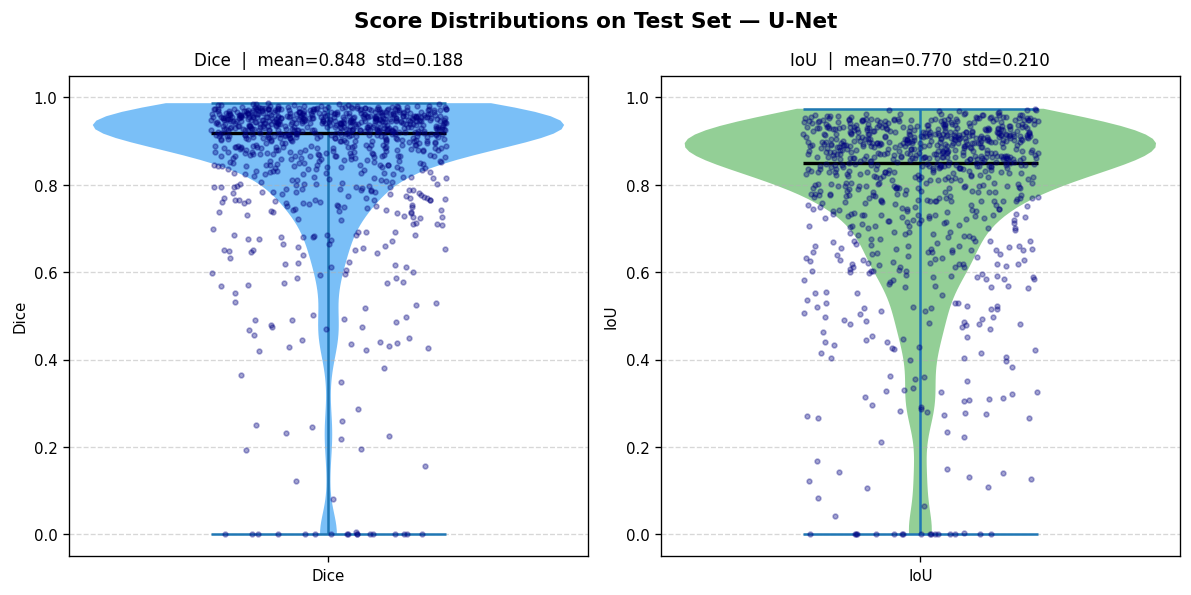

In [ ]:
import pandas as pd

te_violin_df = pd.DataFrame([{'Dice': s['dice'],'IoU' : iou_from_masks(s['gt'], s['pred']) / 100.0} for s in _all_samples])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Score Distributions on Test Set — U-Net', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['Dice', 'IoU'], ['#42A5F5', '#66BB6A']):
    vals = te_violin_df[col].dropna().values
    parts = ax.violinplot(vals, positions=[0], showmedians=True, showextrema=True, widths=0.6)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    jitter = np.random.uniform(-0.15, 0.15, len(vals))
    ax.scatter(jitter, vals, alpha=0.35, s=8, color='navy', zorder=3)
    ax.set_xticks([0]); ax.set_xticklabels([col])
    ax.set_ylabel(col)
    ax.set_title(f'{col}  |  mean={vals.mean():.3f}  std={vals.std():.3f}', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_violin.png', dpi=150, bbox_inches='tight')
plt.show()

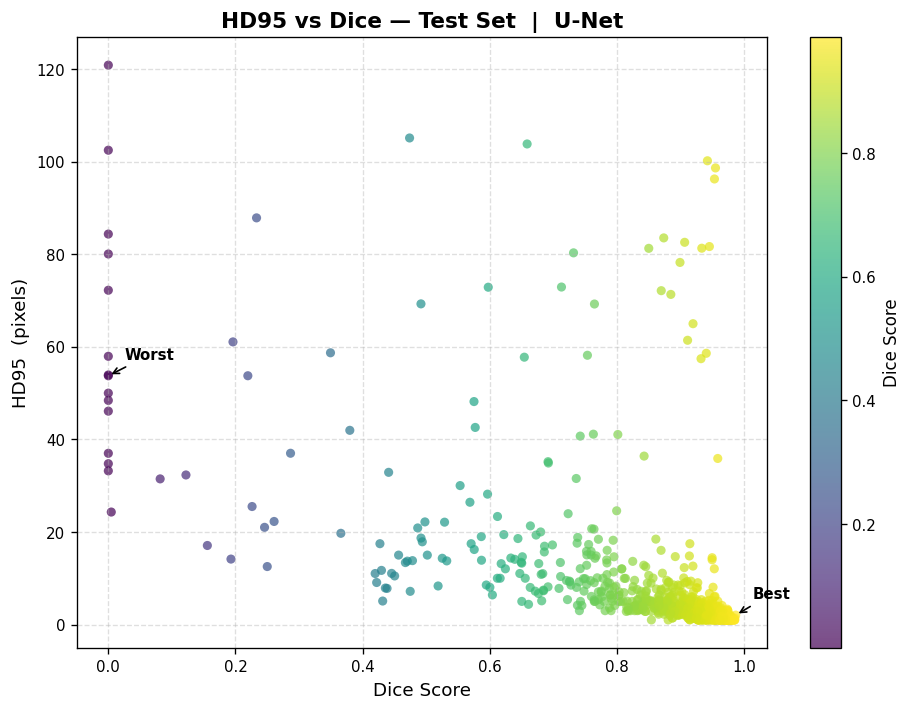

In [ ]:
from medpy.metric.binary import hd95 as _hd95_fn

scatter_records = []
for s in _all_samples:
    p = s['pred'].astype(np.uint8)
    t = s['gt'].astype(np.uint8)
    h = _hd95_fn(p, t) if (p.sum() > 0 and t.sum() > 0) else np.nan
    scatter_records.append({'Dice': s['dice'], 'HD95': h})

sc_df = pd.DataFrame(scatter_records).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(sc_df['Dice'], sc_df['HD95'], c=sc_df['Dice'], cmap='viridis', s=30, alpha=0.7, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Dice Score', fontsize=10)
ax.set_xlabel('Dice Score', fontsize=11)
ax.set_ylabel('HD95  (pixels)', fontsize=11)
ax.set_title('HD95 vs Dice — Test Set  |  U-Net', fontsize=13, fontweight='bold')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
best_r  = sc_df.loc[sc_df['Dice'].idxmax()]
worst_r = sc_df.loc[sc_df['Dice'].idxmin()]
for r, lbl in [(best_r, 'Best'), (worst_r, 'Worst')]:
    ax.annotate(lbl, xy=(r['Dice'], r['HD95']),xytext=(10, 10), textcoords='offset points',
                fontsize=9, fontweight='bold',arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('/kaggle/working/viz_hd95_dice_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(lambda m, inp, out: setattr(self, 'activations', out.clone()))
        target_layer.register_full_backward_hook(lambda m, gin, gout: setattr(self, 'gradients', gout[0].clone()))

    @torch.enable_grad()
    def __call__(self, img_tensor):
        self.model.eval()
        img_tensor = img_tensor.to(CFG.DEVICE)
        logits = self.model(img_tensor)
    
        pred_mask = (torch.sigmoid(logits) > 0.5).float().detach()
        score = (torch.sigmoid(logits) * pred_mask).sum()
        self.model.zero_grad()
        score.backward()
    
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=img_tensor.shape[2:],mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 1e-8:
            cam /= cam.max()
        return cam

target_layer = model.dec1.conv.block[-3]
model.dec1.conv.block[-1].inplace = False
grad_cam = GradCAM(model, target_layer)

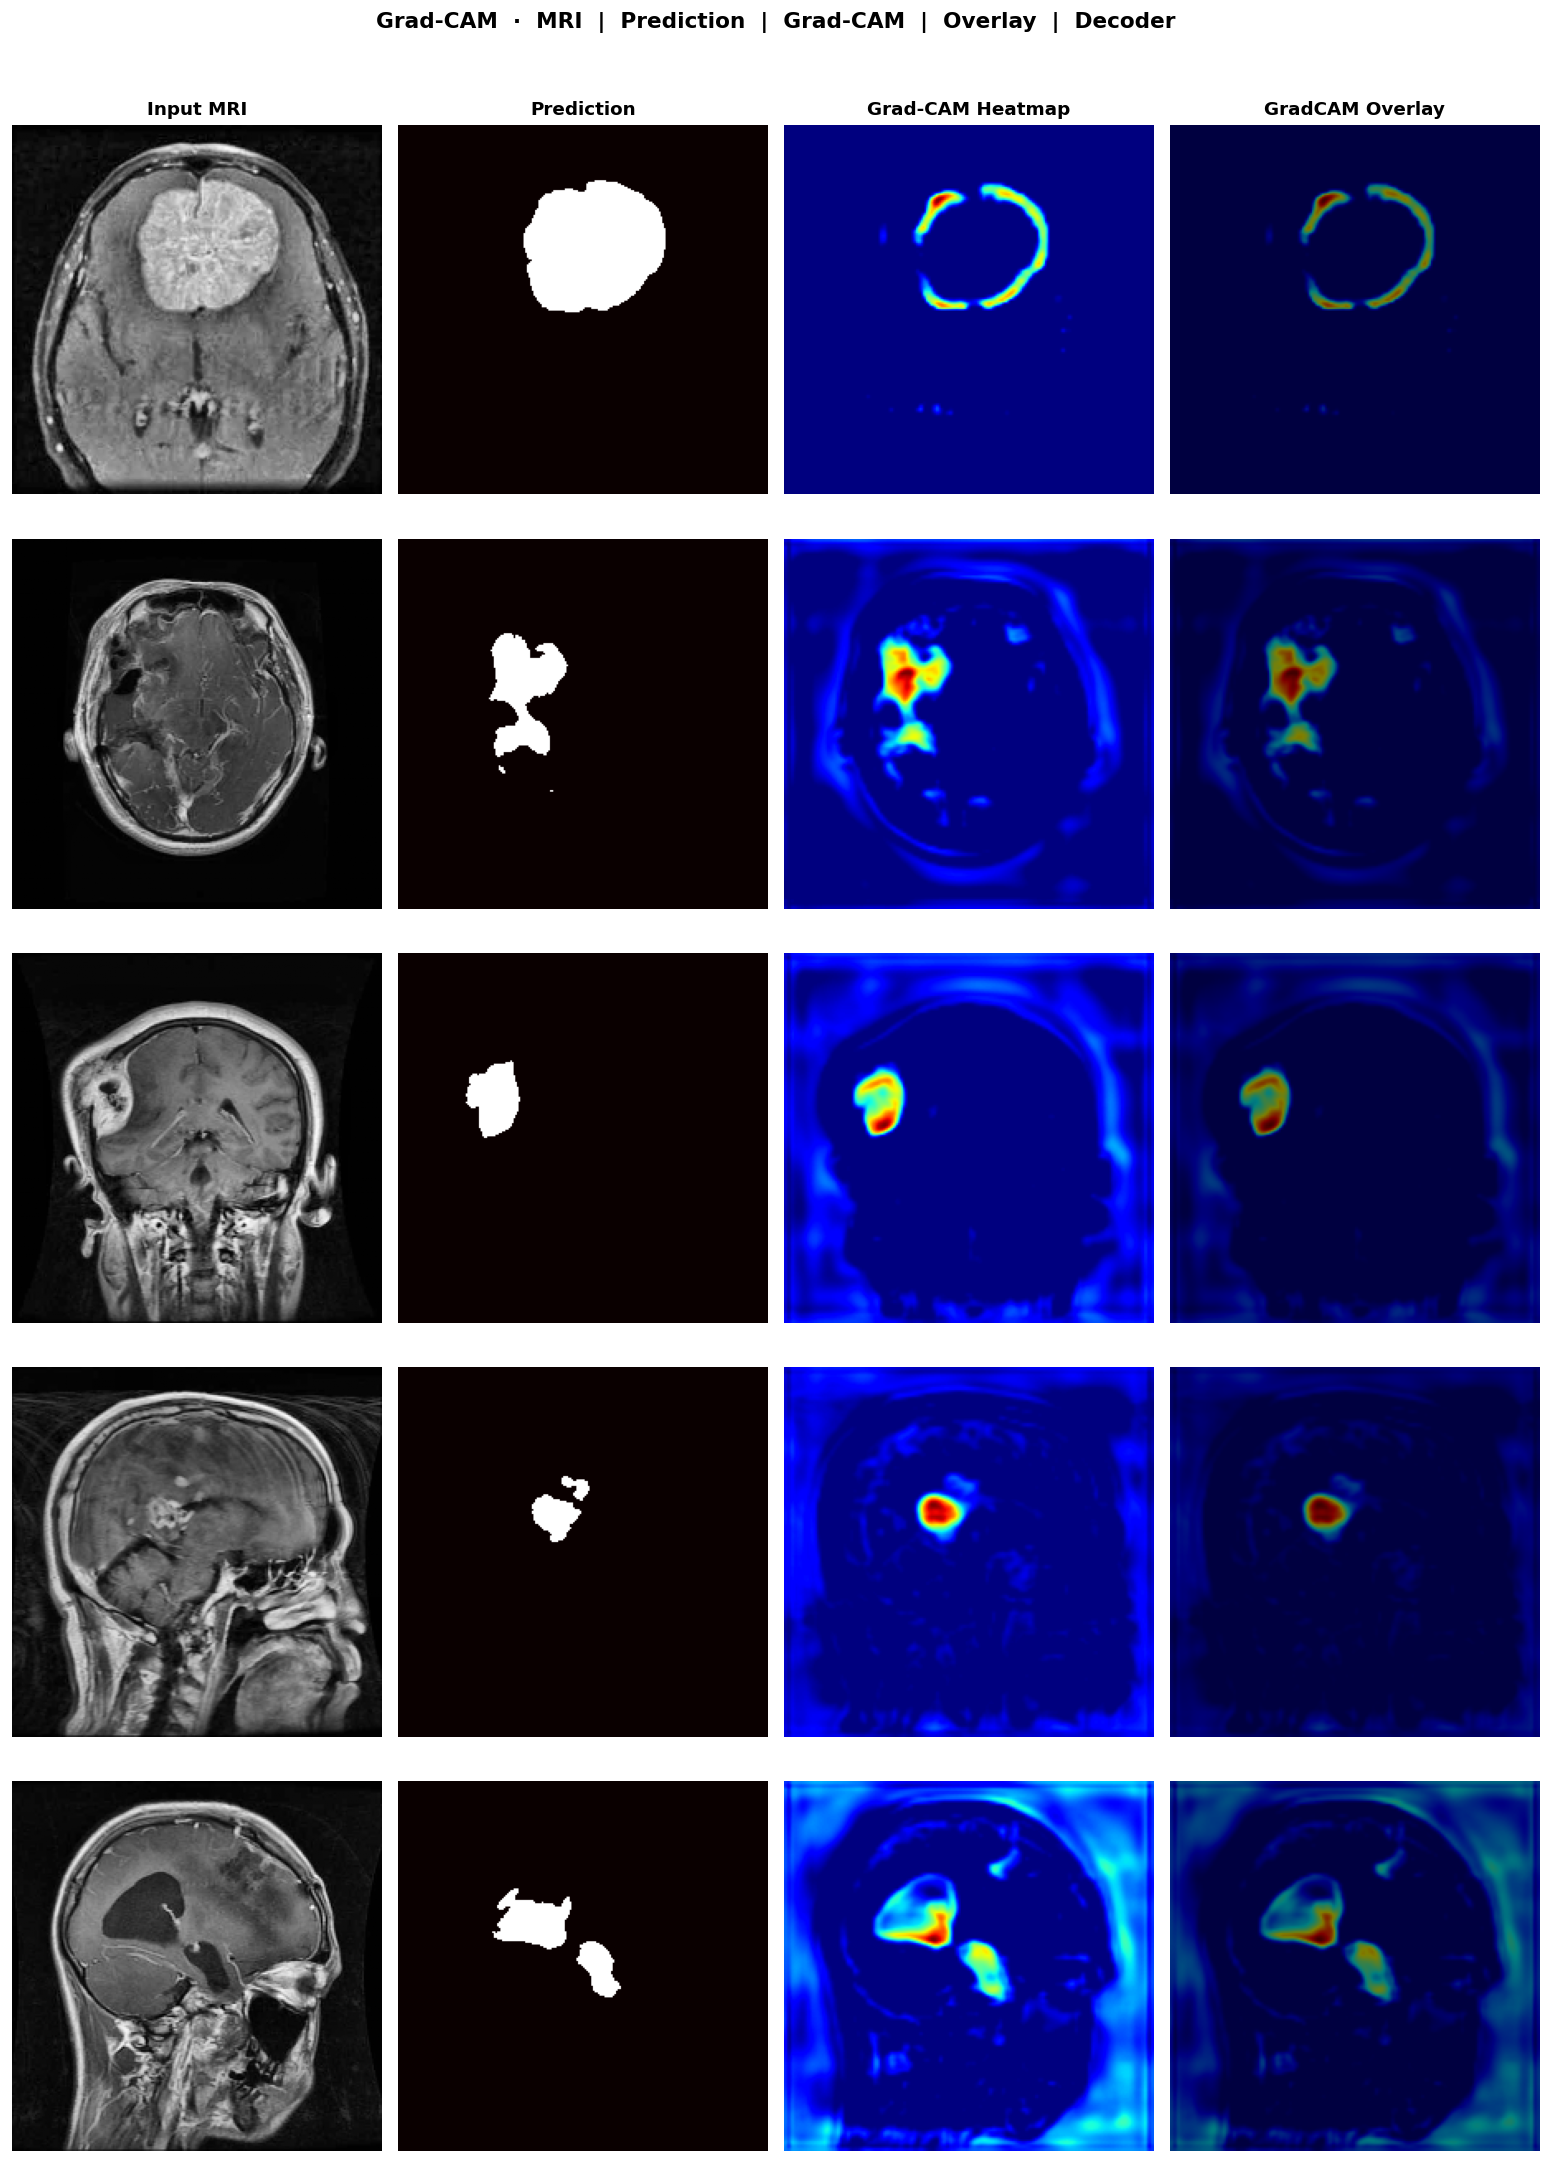

In [ ]:
_random.seed(CFG.SEED + 1)
_mid = _all_sorted[1:-1]
_random3_gc = _random.sample(_mid, 3)
gradcam_5 = [_all_sorted[0]] + _random3_gc + [_all_sorted[-1]]
labels_gc = ['Best'] + [f'Random {i+1}' for i in range(3)] + ['Worst']

fig, axes = plt.subplots(5, 4, figsize=(13, 3.6*5))
fig.suptitle('Grad-CAM  ·  MRI  |  Prediction  |  Grad-CAM  |  Overlay  |  Decoder', fontsize=13, fontweight='bold', y=1.01)

for col, t in enumerate(['Input MRI', 'Prediction', 'Grad-CAM Heatmap', 'GradCAM Overlay']):
    axes[0][col].set_title(t, fontsize=11, fontweight='bold')

for row, (s, lbl) in enumerate(zip(gradcam_5, labels_gc)):
    img_np = s['image']
    pred_np = s['pred']
    img_t = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()
    heatmap = grad_cam(img_t)
    img_u8 = (img_np * 255).clip(0, 255).astype(np.uint8)
    heat_u8 = (heatmap * 255).clip(0, 255).astype(np.uint8)
    heat_rgb = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    overlay = cv2.addWeighted(img_rgb, 0.5, heat_rgb, 0.5, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(img_np,  cmap='gray')
    axes[row][1].imshow(pred_np, cmap='hot')
    axes[row][2].imshow(heatmap, cmap='jet')
    axes[row][3].imshow(overlay)

    axes[row][0].set_ylabel(f'[{lbl}]\nDice={s["dice"]:.4f}', fontsize=9)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_gradcam_5.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target_layer.register_forward_hook(lambda m, inp, out: setattr(self, 'activations', out.clone()))
        target_layer.register_full_backward_hook(lambda m, gin, gout: setattr(self, 'gradients', gout[0].clone()))

    @torch.enable_grad()
    def __call__(self, img_tensor):
        self.model.eval()
        img_tensor = img_tensor.to(CFG.DEVICE)
        logits = self.model(img_tensor)
        pred_mask = (torch.sigmoid(logits) > 0.5).float().detach()
        score = (torch.sigmoid(logits) * pred_mask).sum()
    
        self.model.zero_grad()
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=img_tensor.shape[2:],mode='bilinear', align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 1e-8:
            cam /= cam.max()
        return cam

target_layer = model.bottleneck.conv.block[-3]
model.bottleneck.conv.block[-1].inplace = False
grad_cam = GradCAM(model, target_layer)

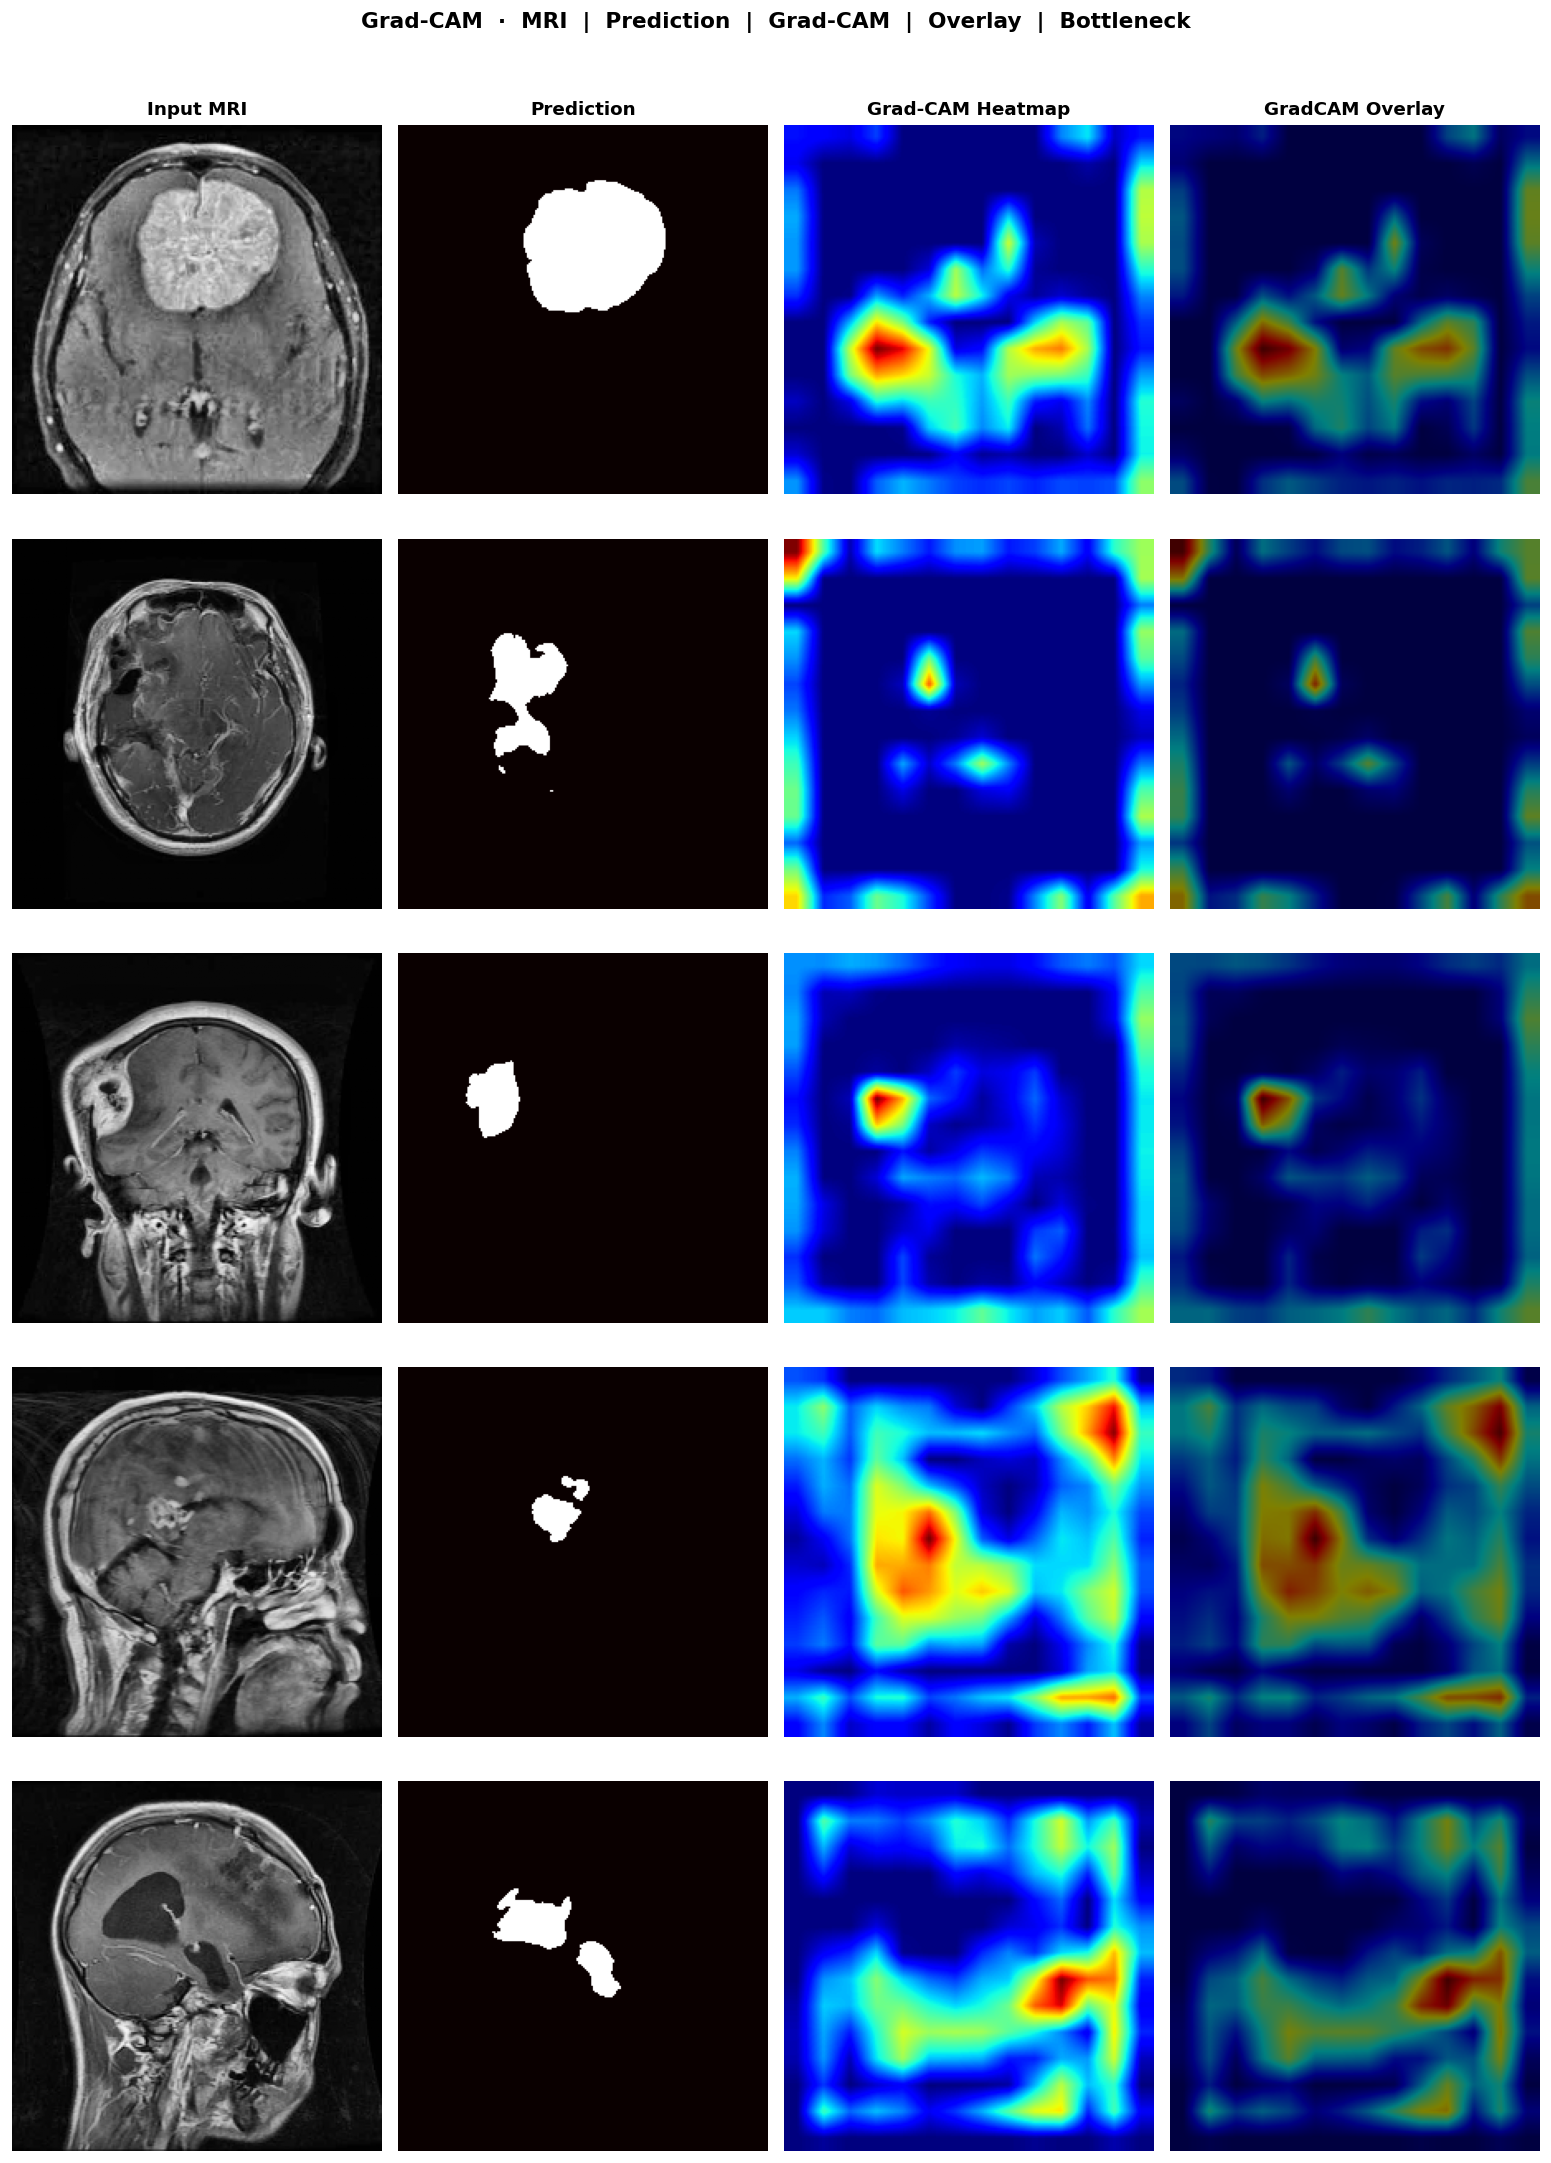

In [ ]:
_random.seed(CFG.SEED + 1)
_mid = _all_sorted[1:-1]
_random3_gc = _random.sample(_mid, 3)
gradcam_5   = [_all_sorted[0]] + _random3_gc + [_all_sorted[-1]]
labels_gc   = ['Best'] + [f'Random {i+1}' for i in range(3)] + ['Worst']

fig, axes = plt.subplots(5, 4, figsize=(13, 3.6*5))
fig.suptitle('Grad-CAM  ·  MRI  |  Prediction  |  Grad-CAM  |  Overlay  |  Bottleneck', fontsize=13, fontweight='bold', y=1.01)

for col, t in enumerate(['Input MRI', 'Prediction', 'Grad-CAM Heatmap', 'GradCAM Overlay']):
    axes[0][col].set_title(t, fontsize=11, fontweight='bold')

for row, (s, lbl) in enumerate(zip(gradcam_5, labels_gc)):
    img_np = s['image']
    pred_np = s['pred']
    img_t  = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()
    heatmap = grad_cam(img_t)
    img_u8 = (img_np * 255).clip(0, 255).astype(np.uint8)
    heat_u8 = (heatmap * 255).clip(0, 255).astype(np.uint8)
    heat_rgb = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    overlay = cv2.addWeighted(img_rgb, 0.5, heat_rgb, 0.5, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(img_np,  cmap='gray')
    axes[row][1].imshow(pred_np, cmap='hot')
    axes[row][2].imshow(heatmap, cmap='jet')
    axes[row][3].imshow(overlay)

    axes[row][0].set_ylabel(f'[{lbl}]\nDice={s["dice"]:.4f}', fontsize=9)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_gradcam_5_1.png', dpi=150, bbox_inches='tight')
plt.show()

Computing occlusion maps 
  [1/5] Best done
  [2/5] Random 1 done
  [3/5] Random 2 done
  [4/5] Random 3 done
  [5/5] Worst done


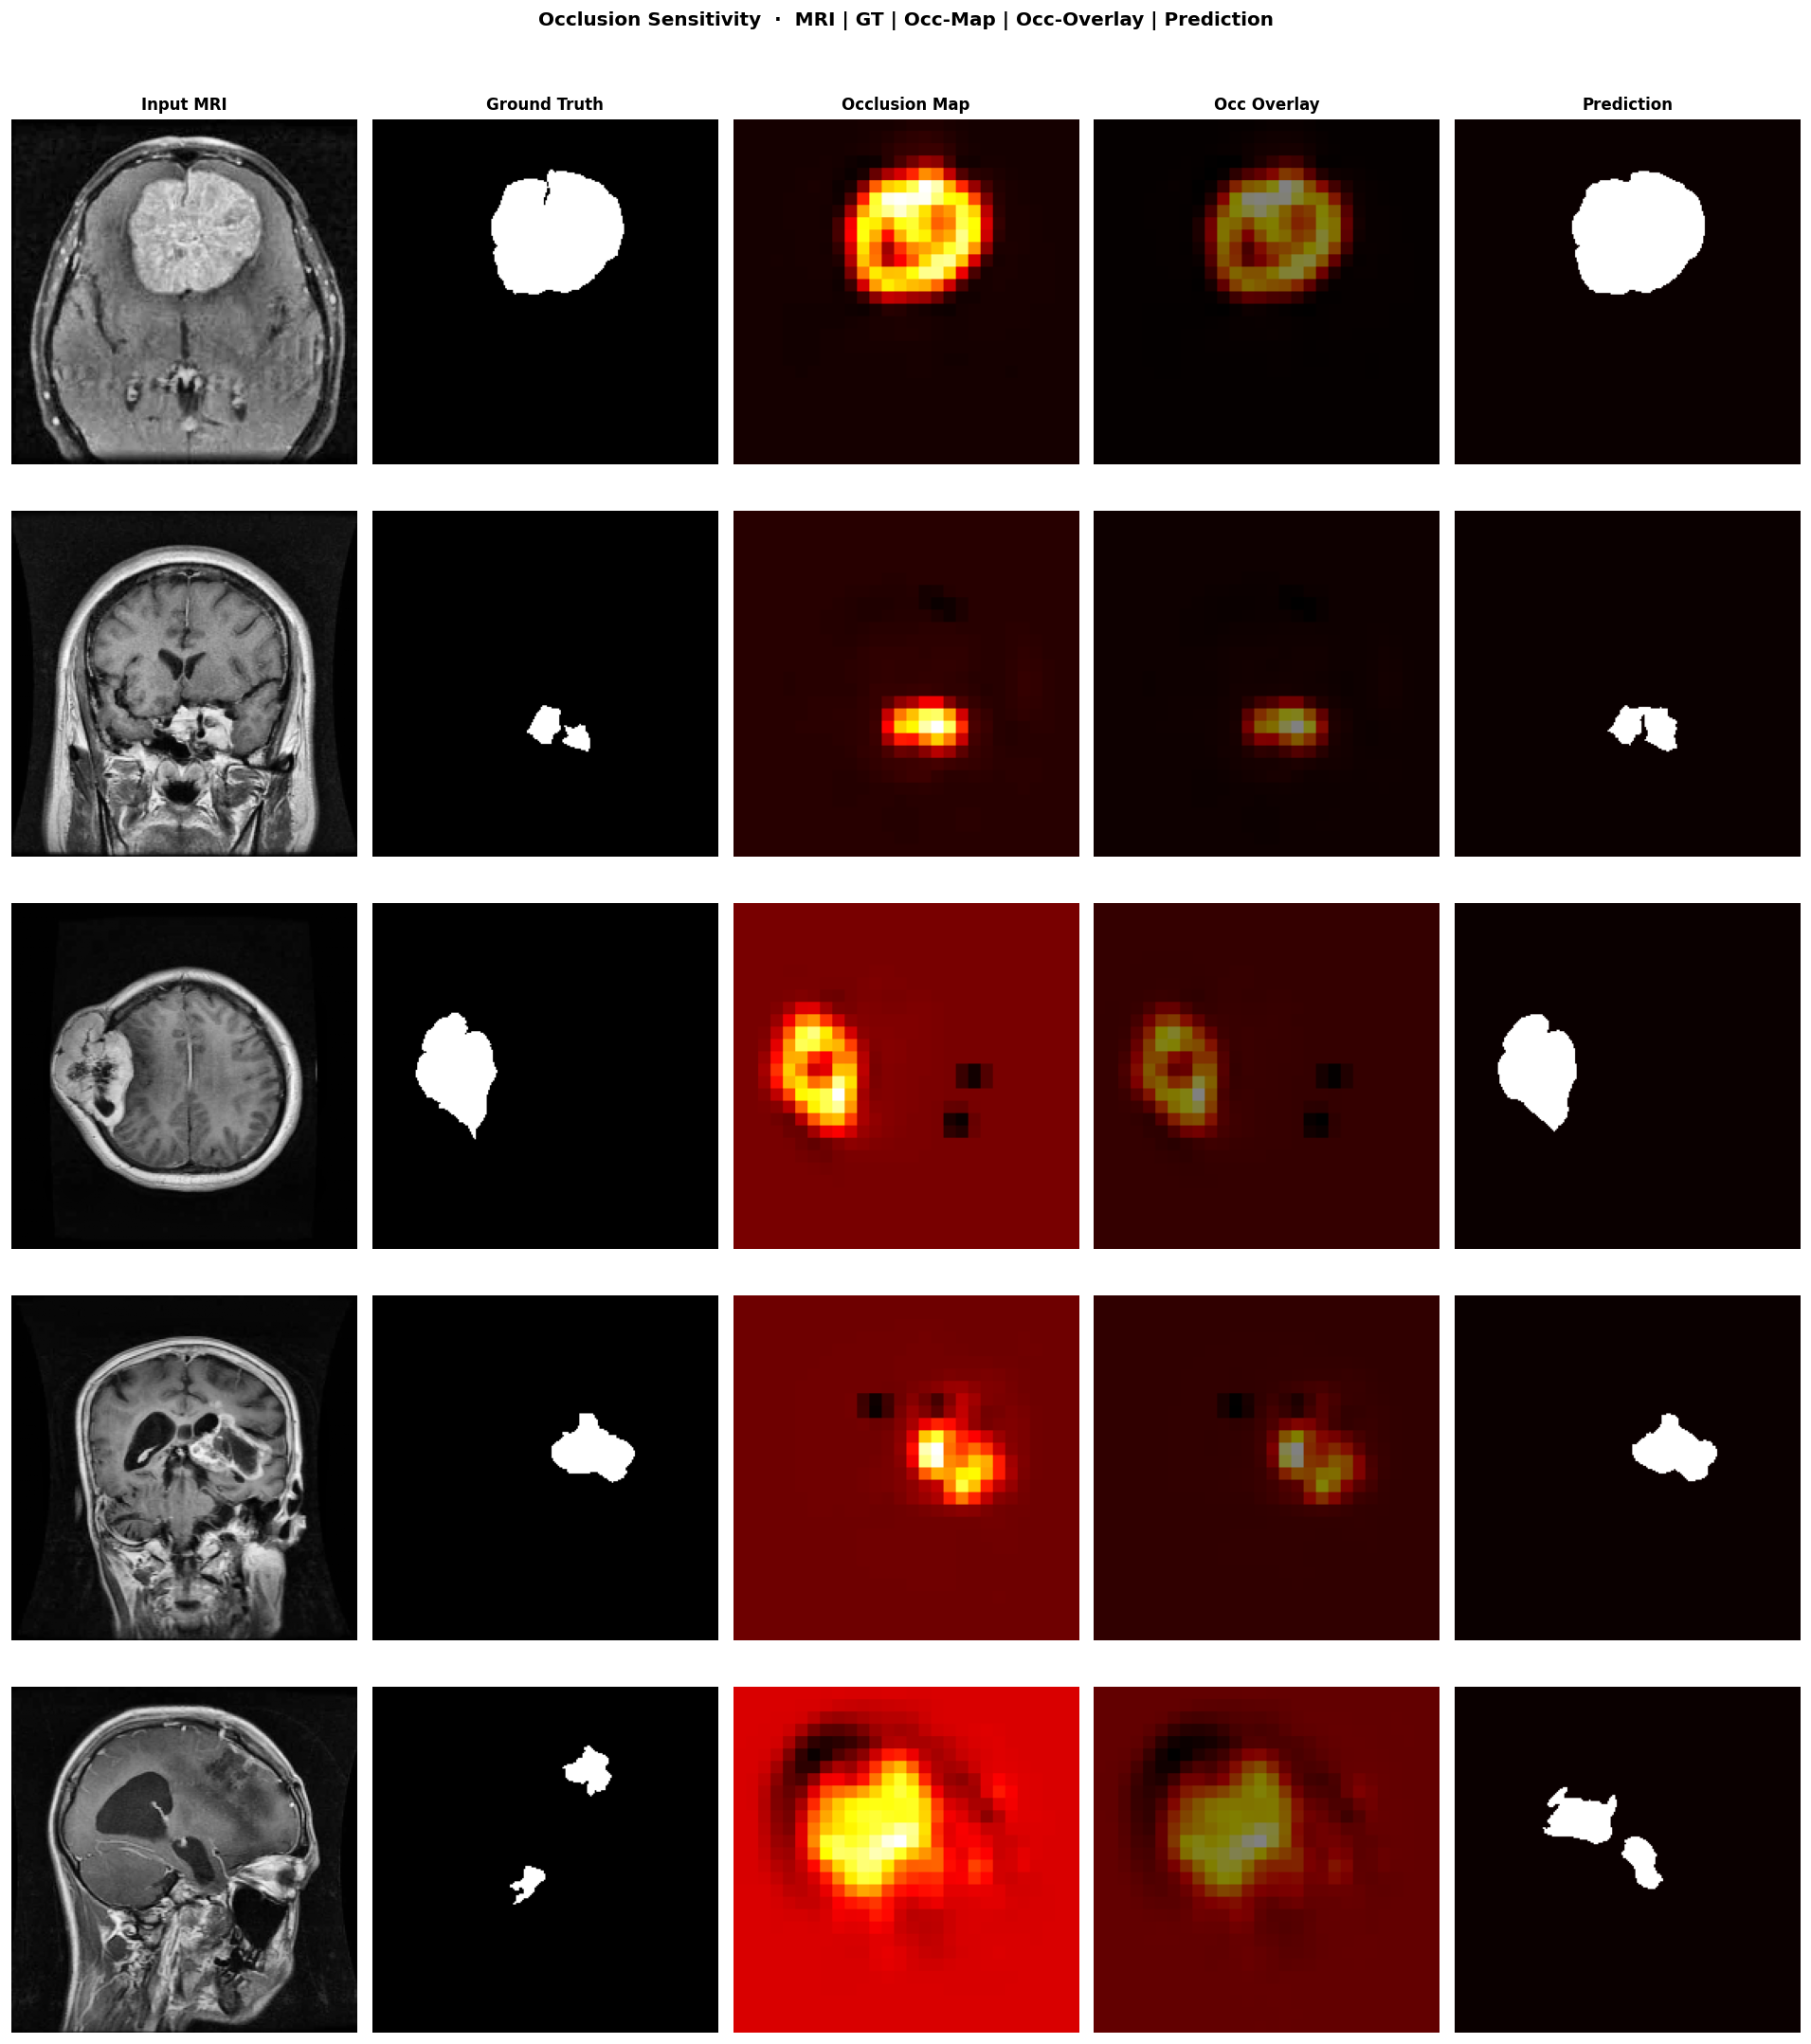

In [ ]:
@torch.no_grad()
def occlusion_sensitivity(model, img_np, patch_size=16, stride=8, device=CFG.DEVICE):
    model.eval()
    H, W = img_np.shape
    img_t = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float().to(device)
    base_score = torch.sigmoid(model(img_t)).mean().item()

    occ_map = np.zeros((H, W), dtype=np.float32)
    count   = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = img_t.clone()
            occluded[:, :, y:y+patch_size, x:x+patch_size] = 0.0
            score = torch.sigmoid(model(occluded)).mean().item()
            drop  = base_score - score
            occ_map[y:y+patch_size, x:x+patch_size] += drop
            count  [y:y+patch_size, x:x+patch_size] += 1.0

    count = np.maximum(count, 1e-8)
    occ_map /= count
    occ_map -= occ_map.min()
    if occ_map.max() > 1e-8:
        occ_map /= occ_map.max()
    return occ_map

_random.seed(CFG.SEED + 2)
_mid2 = _all_sorted[1:-1]
_random3_occ = _random.sample(_mid2, 3)
occ_5  = [_all_sorted[0]] + _random3_occ + [_all_sorted[-1]]
labels_occ = ['Best'] + [f'Random {i+1}' for i in range(3)] + ['Worst']

print('Computing occlusion maps ')
fig, axes = plt.subplots(5, 5, figsize=(16, 3.6*5))
fig.suptitle('Occlusion Sensitivity  ·  MRI | GT | Occ-Map | Occ-Overlay | Prediction',fontsize=12, fontweight='bold', y=1.01)

col_titles = ['Input MRI', 'Ground Truth', 'Occlusion Map', 'Occ Overlay', 'Prediction']
for col, t in enumerate(col_titles):
    axes[0][col].set_title(t, fontsize=10, fontweight='bold')

for row, (s, lbl) in enumerate(zip(occ_5, labels_occ)):
    img_np = s['image']
    gt_np = s['gt']
    pred_np = s['pred']
    occ_map = occlusion_sensitivity(model, img_np)

    img_u8 = (img_np * 255).clip(0,255).astype(np.uint8)
    occ_u8 = (occ_map * 255).clip(0,255).astype(np.uint8)
    occ_rgb = cv2.applyColorMap(occ_u8, cv2.COLORMAP_HOT)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    occ_ovl = cv2.addWeighted(img_rgb, 0.5, occ_rgb, 0.5, 0)
    occ_ovl = cv2.cvtColor(occ_ovl, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(img_np,cmap='gray')
    axes[row][1].imshow(gt_np,cmap='gray')
    axes[row][2].imshow(occ_map,cmap='hot')
    axes[row][3].imshow(occ_ovl)
    axes[row][4].imshow(pred_np,cmap='hot')

    axes[row][0].set_ylabel(f'[{lbl}]\nDice={s["dice"]:.4f}', fontsize=9)
    for ax in axes[row]: ax.axis('off')
    print(f'  [{row+1}/5] {lbl} done')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_occlusion_5.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary

In [41]:
total_params, _ = count_params(model)
te_df = pd.DataFrame(te_records)

print('=' * 72)
print('FINAL SUMMARY — BRISC-25  U-Net Brain MRI Segmentation')
print('=' * 72)
print(f'  Best epoch         : {best_epoch} / {CFG.EPOCHS}')
print(f'  Total parameters   : {total_params:,}  ({total_params/1e6:.2f} M)')
print(f'  Image size         : {CFG.IMAGE_SIZE}×{CFG.IMAGE_SIZE}')
print(f'  Batch size         : {CFG.BATCH_SIZE}')
print(f'  Loss               : {CFG.FOCAL_WEIGHT}×Focal(α={CFG.FOCAL_ALPHA}, γ={CFG.FOCAL_GAMMA}) + {CFG.DICE_WEIGHT}×Dice')
print(f'  Optimizer          : AdamW  (lr={CFG.LR}, wd={CFG.WEIGHT_DECAY})')
print(f'  Scheduler          : CosineAnnealingLR  (T_max={CFG.EPOCHS})')
print()

metrics_display = {
    'Dice':        'dice',
    'IoU':         'iou',
    'HD95':        'hd95',
    'Precision':   'precision',
    'Recall':      'recall',
    'Specificity': 'specificity',
}

print(f"| {'Metric':<14} | {'Test Mean':>12} | {'Test Std':>10} |")
print(f"|{'-'*16}|{'-'*14}|{'-'*12}|")
for display_name, col in metrics_display.items():
    vals = te_df[col].dropna()
    print(f"| {display_name:<14} | {vals.mean():>12.4f} | {vals.std():>10.4f} |")

print()
print(f'  Best Val Dice      : {best_val_dice:.4f}')
print(f'  Saved to           : {CFG.BEST_CKPT}')
print('=' * 72)

FINAL SUMMARY — BRISC-25  U-Net Brain MRI Segmentation
  Best epoch         : 48 / 50
  Total parameters   : 31,383,681  (31.38 M)
  Image size         : 224×224
  Batch size         : 8
  Loss               : 0.5×Focal(α=0.25, γ=2.0) + 0.5×Dice
  Optimizer          : AdamW  (lr=0.0001, wd=1e-05)
  Scheduler          : CosineAnnealingLR  (T_max=50)

| Metric         |    Test Mean |   Test Std |
|----------------|--------------|------------|
| Dice           |       0.8482 |     0.1880 |
| IoU            |       0.7699 |     0.2101 |
| HD95           |       8.6241 |    16.2359 |
| Precision      |       0.8622 |     0.1946 |
| Recall         |       0.8692 |     0.1881 |
| Specificity    |       0.9980 |     0.0037 |

  Best Val Dice      : 0.8585
  Saved to           : /kaggle/working/models/unet_best.pth
